# Value Based Segmentation for Amazing International Airlines Inc
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----
# Exploratory Data Analysis (EDA) 
## Summary

Value-based segmentation, grouping customers according to their economic contribution.

<a class="anchor" id='toc'></a> 
<div class="alert alert-block alert-info">

## **Index**<br>

[**Imports**](#0-bullet)<br>

[**Metadata**](#1-bullet)<br>

[**Data Preprocessing**](#1st-bullet)<br>
- [**Inconcistances**](#2nd-bullet)<br>
- [**Outliers**](#2nd-bullet)<br>
- [**Scaling**](#1st-bullet)<br>
    - [Robust Scaler](#3rd-bullet)<br>

[**Clustering**](#1st-bullet)<br>
- [**KNN**](#2nd-bullet)<br>
- [**KNN**](#2nd-bullet)<br>

    
</div>

<a class="anchor" id="0-bullet">    </a>
# Imports
[Back to Index](#toc)

In [1135]:

# Standard library imports
import os
import warnings
from math import ceil


# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    confusion_matrix,
    classification_report,
    accuracy_score,
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

import umap

# Local application imports
from utils_clustering import (
    visualize_dimensionality_reduction,
    plot_comparing_avr_clusters,
    plot_dendrogram,
)

# Configuration
RANDOM_STATE = 42
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

sns.set_context("notebook")
sns.set_style("ticks")


In [1136]:
MasterCustomerDB_Complete = pd.read_csv('../../data/DM_AIAI_MasterCustomerDB.csv')
MasterCustomerDB = MasterCustomerDB_Complete.copy()

In [1137]:
cols_to_keep = [
    'Loyalty#',
    'Customer Lifetime Value',
    'Days_with_us',
    'Days_until_reengagement',
    'Total_NumFlights',
    'Total_DistanceKM',
    'Perc_Flights_With_Companions',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]

Value_Based_Segmentation_clustering = MasterCustomerDB[cols_to_keep].copy()
Value_Based_Segmentation_clustering = Value_Based_Segmentation_clustering.set_index('Loyalty#')

<a class="anchor" id="value-based-segmentation">    </a>
### Metadata – Value-Based Segmentation
[Back to Index](#toc)

**Preprocessed & Merged Dataset**

*This dataset is derived from the integration and transformation of `DM_AIAI_CustomerDB.csv` and `DM_AIAI_FlightsDB.csv`.  
It contains engineered features designed to support value-based customer segmentation, focusing on customer profitability, loyalty behavior, and engagement over time.*

### Variables

- *Customer Lifetime Value* – Total estimated monetary value generated by the customer over the duration of the relationship

- *Days_with_us* – Total number of days the customer has been active in the loyalty program since enrollment

- *Days_until_reengagement* – Number of days between cancellation and re-engagement for returning customers

- *Total_NumFlights* – Total number of flights taken by the customer during the observed period

- *Total_DistanceKM* – Total cumulative flight distance traveled by the customer in kilometers

- *Perc_Flights_With_Companions* – Percentage of flights taken with companions relative to the customer’s total flights

- *Dollar_Cost_Points_Remaining* – Estimated dollar value of loyalty points accumulated but not yet redeemed by the customer

- *Recency_Days* – Number of days since the customer’s most recent flight activity


# Preprocessing

Lets explore our EDA data set on NA and negativenumbers

In [1138]:
Value_Based_Segmentation_clustering.isna().sum()


Customer Lifetime Value             0
Days_with_us                        0
Days_until_reengagement         16373
Total_NumFlights                 1471
Total_DistanceKM                 1471
Perc_Flights_With_Companions     1471
Dollar_Cost_Points_Remaining     1471
Recency_Days                     1471
dtype: int64

In [1139]:
(Value_Based_Segmentation_clustering < 0).sum()

Customer Lifetime Value           0
Days_with_us                      0
Days_until_reengagement           0
Total_NumFlights                  0
Total_DistanceKM                  0
Perc_Flights_With_Companions      0
Dollar_Cost_Points_Remaining    481
Recency_Days                      0
dtype: int64

### Data Cleaning Steps

We proceed step by step with the data preparation:

1. **Days Until Re-engagement**  
   - `Days_until_reengagement` has **16,373 missing values**.  
   - These missing values correspond to customers who **did not leave the program**.  
   - We therefore impute these missing values with **0**.

2. **Value-Based Transaction Features**  
The following variables contain **1,471 missing values**:  
   - `Total_NumFlights`  
   - `Total_DistanceKM`  
   - `Dollar_Cost_Points_Remaining`  
   - `Recency_Days`  
These missing values indicate customers who **have not made any transactions**. Instead of imputing, we isolate these observations into a separate cluster labeled **“No Transaction”**.

3. **Negative Point Balances**  
There are **481 observations** with negative values in `Dollar_Cost_Points_Remaining`.  
Since it is not meaningful for a customer to redeem more points than they have earned,  
     we apply a **lower bound (floor) of 0** to this variable.


Identify “No Transaction” customers

In [1140]:
transaction_cols = [
    'Total_NumFlights',
    'Total_DistanceKM',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]
no_transaction_mask = Value_Based_Segmentation_clustering[transaction_cols].isna().any(axis=1)
Value_Based_Segmentation_clustering_no_transaction = Value_Based_Segmentation_clustering[no_transaction_mask].copy()


Value_Based_Segmentation_clustering = Value_Based_Segmentation_clustering.dropna(subset=transaction_cols)

print(Value_Based_Segmentation_clustering_no_transaction.shape[0])


1471


Days_until_reengagement → impute with 0

In [1141]:
Value_Based_Segmentation_clustering['Days_until_reengagement'] = (
    Value_Based_Segmentation_clustering['Days_until_reengagement']
    .fillna(0)
)

Negative Dollar_Cost_Points_Remaining → floor at 0

In [1142]:
Value_Based_Segmentation_clustering['Dollar_Cost_Points_Remaining'] = (
    Value_Based_Segmentation_clustering['Dollar_Cost_Points_Remaining']
    .clip(lower=0)
)

Quick sanity checks

In [1143]:
# Check remaining missing values
print(Value_Based_Segmentation_clustering.isna().sum())

# Check negative values
print((Value_Based_Segmentation_clustering < 0).sum())
# Check transaction group sizes
print(Value_Based_Segmentation_clustering_no_transaction.shape[0])


Customer Lifetime Value         0
Days_with_us                    0
Days_until_reengagement         0
Total_NumFlights                0
Total_DistanceKM                0
Perc_Flights_With_Companions    0
Dollar_Cost_Points_Remaining    0
Recency_Days                    0
dtype: int64
Customer Lifetime Value         0
Days_with_us                    0
Days_until_reengagement         0
Total_NumFlights                0
Total_DistanceKM                0
Perc_Flights_With_Companions    0
Dollar_Cost_Points_Remaining    0
Recency_Days                    0
dtype: int64
1471


## Visualisation

### Extreme Outlier Reference (3×IQR)

In addition to standard boxplots, we include a visual reference for *extreme outliers* using the **3× interquartile range (IQR)** rule.

While the conventional 1.5×IQR threshold highlights moderately unusual observations, the 3×IQR threshold identifies values that are *extremely distant* from the central distribution.

Importantly, these thresholds are **not used for automatic removal**.  
They are included solely as a diagnostic and interpretative tool to support exploratory data analysis and to assess whether certain variables contain values that may disproportionately influence visualization or downstream modeling.

Extreme outlier boundaries are displayed only when such values are present in the data.


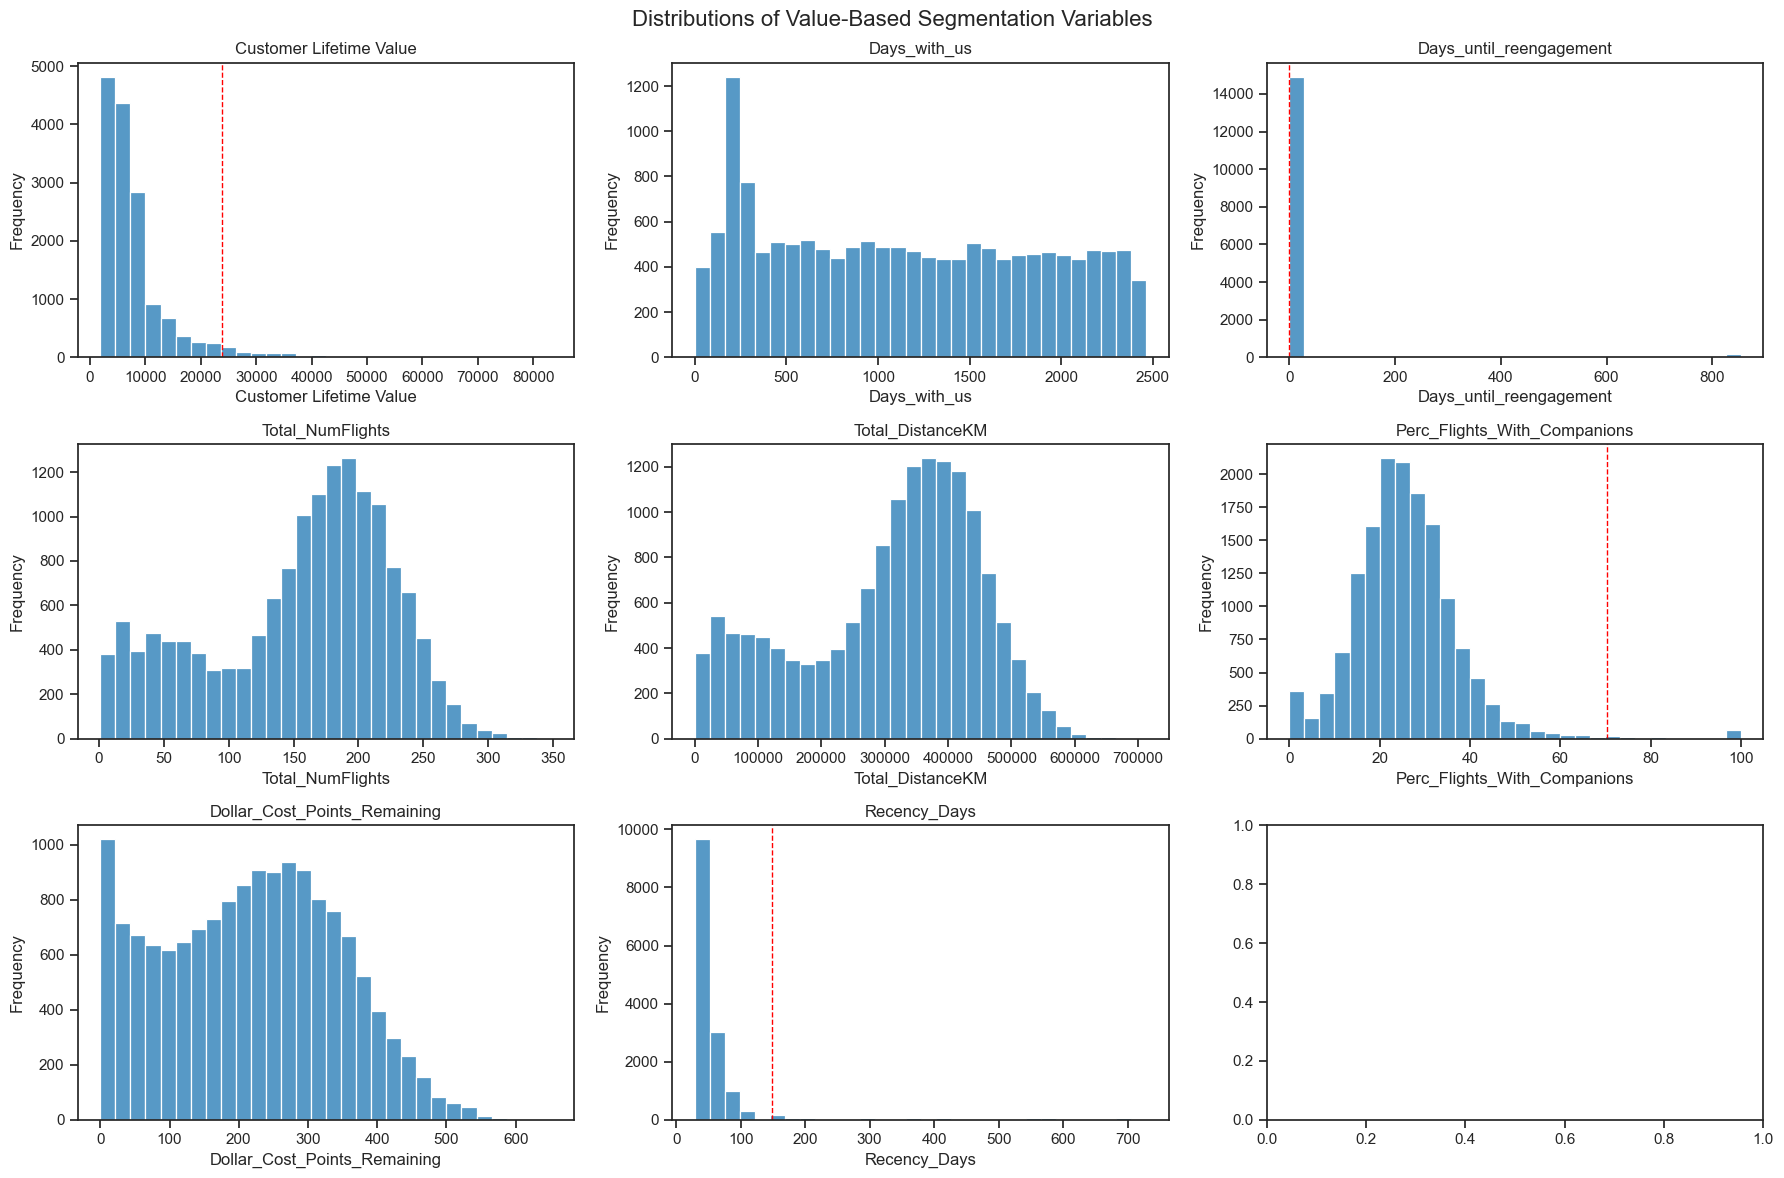

In [1144]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):

    data = Value_Based_Segmentation_clustering[col].dropna()

    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr

    # Plot histogram
    sns.histplot(data, bins=30, ax=ax)

    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)

    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Value-Based Segmentation Variables", fontsize=16)
plt.tight_layout()
plt.show()
# ...existing code...

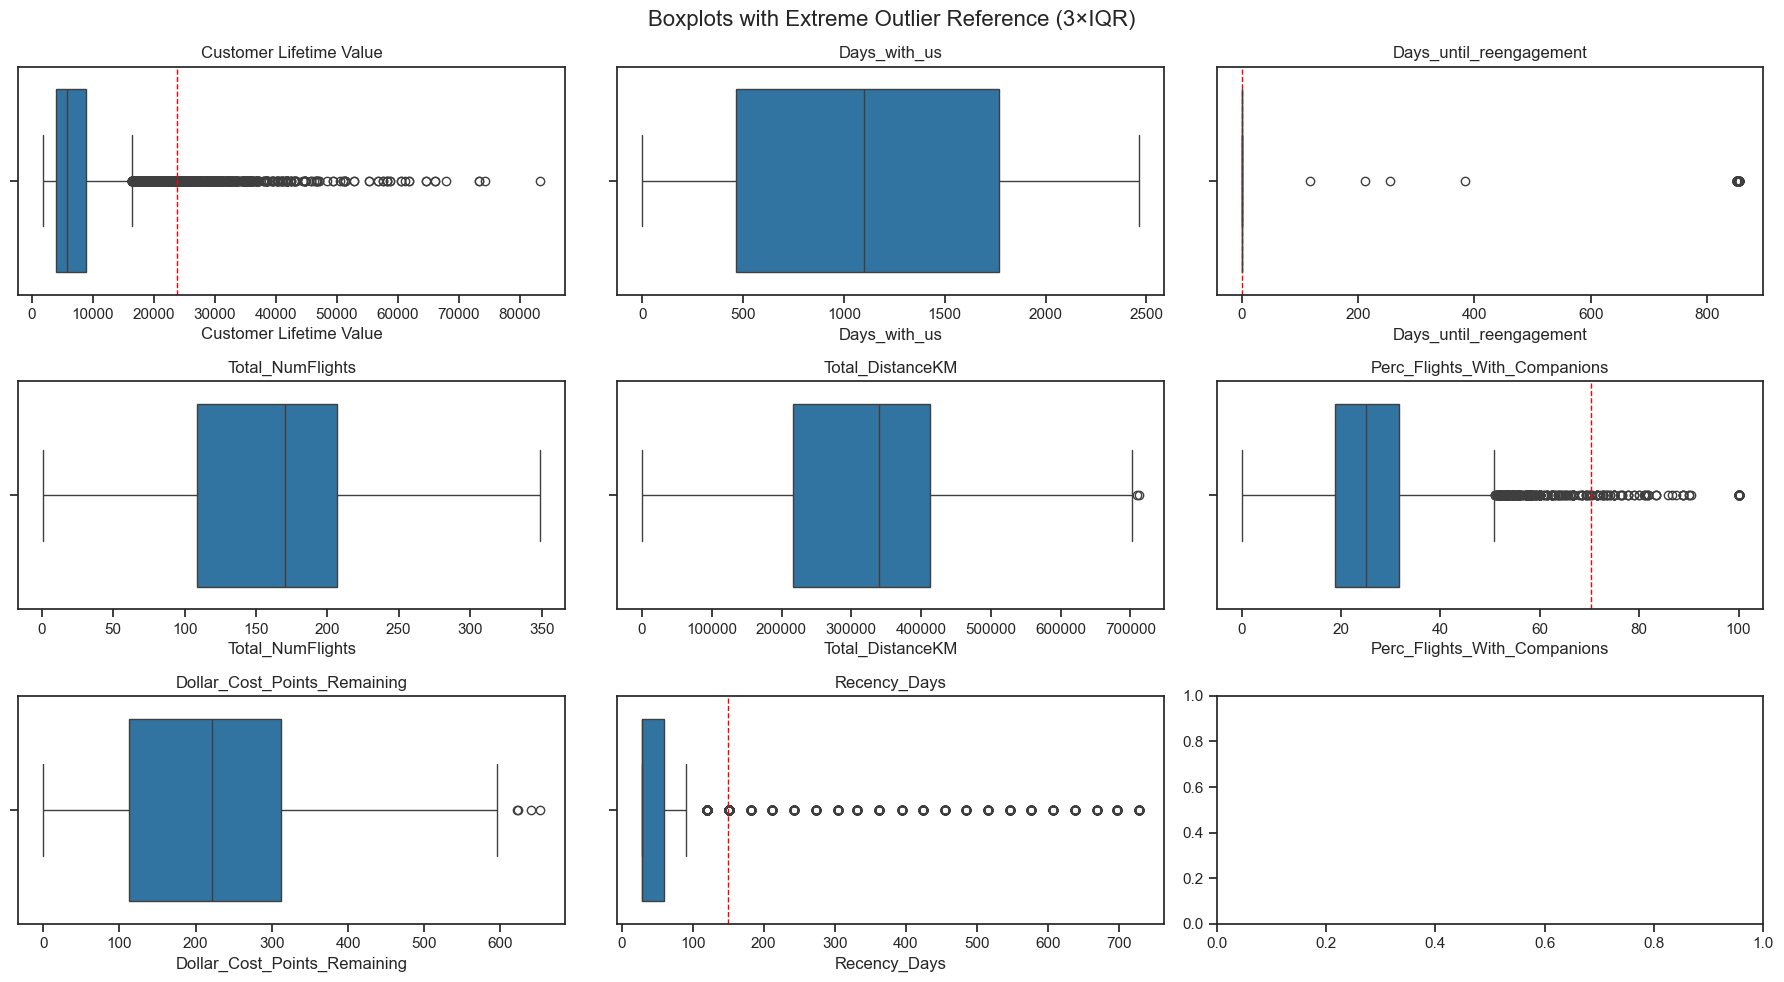

In [1145]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr
    
    # Boxplot
    sns.boxplot(x=data, ax=ax)
    
    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)
        
    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots with Extreme Outlier Reference (3×IQR)",
    fontsize=16
)
plt.tight_layout()
plt.show()


Overall, the graphs look acceptable. There is some right skewness, but it does not appear to be a major issue at this stage.</br></br>
The main parameters that require closer inspection are Customer Lifetime Value, Days Until, Percentage of Flights with Companions, and Recency Days Reengagement. We analyze these features one by one to understand whether the extreme values represent true outliers or meaningful customer behavior. This assessment will help decide whether they should be preserved for clustering or handled during the scaling step.

## Outliers Detection

### Customer Lifetime Value

Customer Lifetime Value is a core variable in value-based segmentation. Extremely high values may indicate highly valuable customers rather than noise, so they should not be removed without careful consideration.
To better understand the distribution, we examine the percentage of customers with a lifetime value above our 'extreme outliers point' - 3*Inter qurtile range.

In [1146]:
clv = Value_Based_Segmentation_clustering['Customer Lifetime Value']
Q1 = clv.quantile(0.25)
Q3 = clv.quantile(0.75)
IQR = Q3 - Q1

clv_upper_3iqr = Q3 + 3 * IQR

clv_perc_above_3iqr = (clv > clv_upper_3iqr).mean() * 100

clv_perc_above_3iqr


np.float64(3.8275610886696247)

The percentage of extreme values is 3% (a few), and since these customers remain high-value, we will apply a ceiling to limit values above three times the upper quartile. This helps reduce the impact of extremes and can potentially improve clustering results.

In [1147]:
Value_Based_Segmentation_clustering['Customer Lifetime Value'] = (
    Value_Based_Segmentation_clustering['Customer Lifetime Value']
    .clip(upper=clv_upper_3iqr)
)

In [1148]:
print(Value_Based_Segmentation_clustering['Customer Lifetime Value'].max() == clv_upper_3iqr)

True


### Days until reengagement

This variable contains a large number of zeros, which correspond to customers who never left the program. In this case, standard outlier detection methods such as IQR are not informative.
To better understand the behavior of this feature, we analyze its distribution after excluding active users. This allows us to focus on customers who actually disengaged and observe how reengagement time is distributed.

In [1149]:
dur = Value_Based_Segmentation_clustering['Days_until_reengagement']

# Percentage of zeros
perc_zero = (dur == 0).mean() * 100
print(perc_zero)

98.82127011456195


In [1150]:
perc_800= (dur > 800).mean() * 100
print(perc_800)
print(perc_800 + perc_zero)

1.1522415734057347
99.97351168796769


A small fraction of customers (around 2%) shows extremely long re-engagement periods, in some cases exceeding 800 days. These customers typically flew with us, left the program, and rejoined after a long gap(for example due to promotion).
Although these values are extreme compared to the rest of the dataset, they reflect real customer behavior rather than noise.
Based on this, we during clusteing we will be carefull with this feature but wont change this feature and will not apply ceiling at this stage.

### Percentage of Flights With Companions

This feature presents a situation similar to Customer Lifetime Value. While extreme values exist, they may reflect meaningful travel behavior rather than noise.
Before moving forward, it is important to examine how the data behaves at the extremes of this variable. Since this feature is essential for clustering, the decision on how to handle these values should be made carefully, balancing robustness with the need to preserve relevant customer patterns.

In [1151]:
companions = Value_Based_Segmentation_clustering['Perc_Flights_With_Companions']
Q1 = companions.quantile(0.25)
Q3 = companions.quantile(0.75)
IQR = Q3 - Q1

companions_upper_3iqr = Q3 + 3 * IQR

companions_perc_above_3iqr = (companions > companions_upper_3iqr).mean() * 100

print(companions_perc_above_3iqr)
plt.show()

0.8343818290179458


About 1% of the records are above the extreme threshold. Although this is a small number, we can’t rescale the feature because it’s in percentages, and keeping the 0–100 scale is important. These customers still matter in the analysis, so we should keep them in mind during clustering.

### Recency Days

This situation is similar to what we observed with Customer Lifetime Value and Percentage of Flights With Companions. To proceed, it is important to examine how the data behaves at the extremes for this feature. Since it is essential for clustering, any decisions on handling extreme values should carefully balance preserving meaningful patterns with ensuring robust analysis.

In [1152]:
recency = Value_Based_Segmentation_clustering['Recency_Days']
Q1 = recency.quantile(0.25)
Q3 = recency.quantile(0.75)
IQR = Q3 - Q1

recency_upper_3iqr = Q3 + 3 * IQR

recency_perc_above_3iqr = (recency > recency_upper_3iqr).mean() * 100

recency_perc_above_3iqr

np.float64(7.284285808886828)

There are quite a few observations, but if we consider typical travel behavior (most people don’t fly more than once a year for vacations) it makes to observe   flights occurring once a year two or more together

In [1153]:
perc_above_365 = (recency > 365).mean() * 100
print(perc_above_365)


3.66863121647573


At this point we consider customers with long recency periods(>>3*Quartile) as extreme values in the dataset. To limit their impact on clustering while preserving overall patterns, we can apply a ceiling and set all recency values above 365 days to 365

In [1154]:
Value_Based_Segmentation_clustering['Recency_Days'] = (
    Value_Based_Segmentation_clustering['Recency_Days']
    .clip(upper=365)
)

### Visualizations after working on outliers

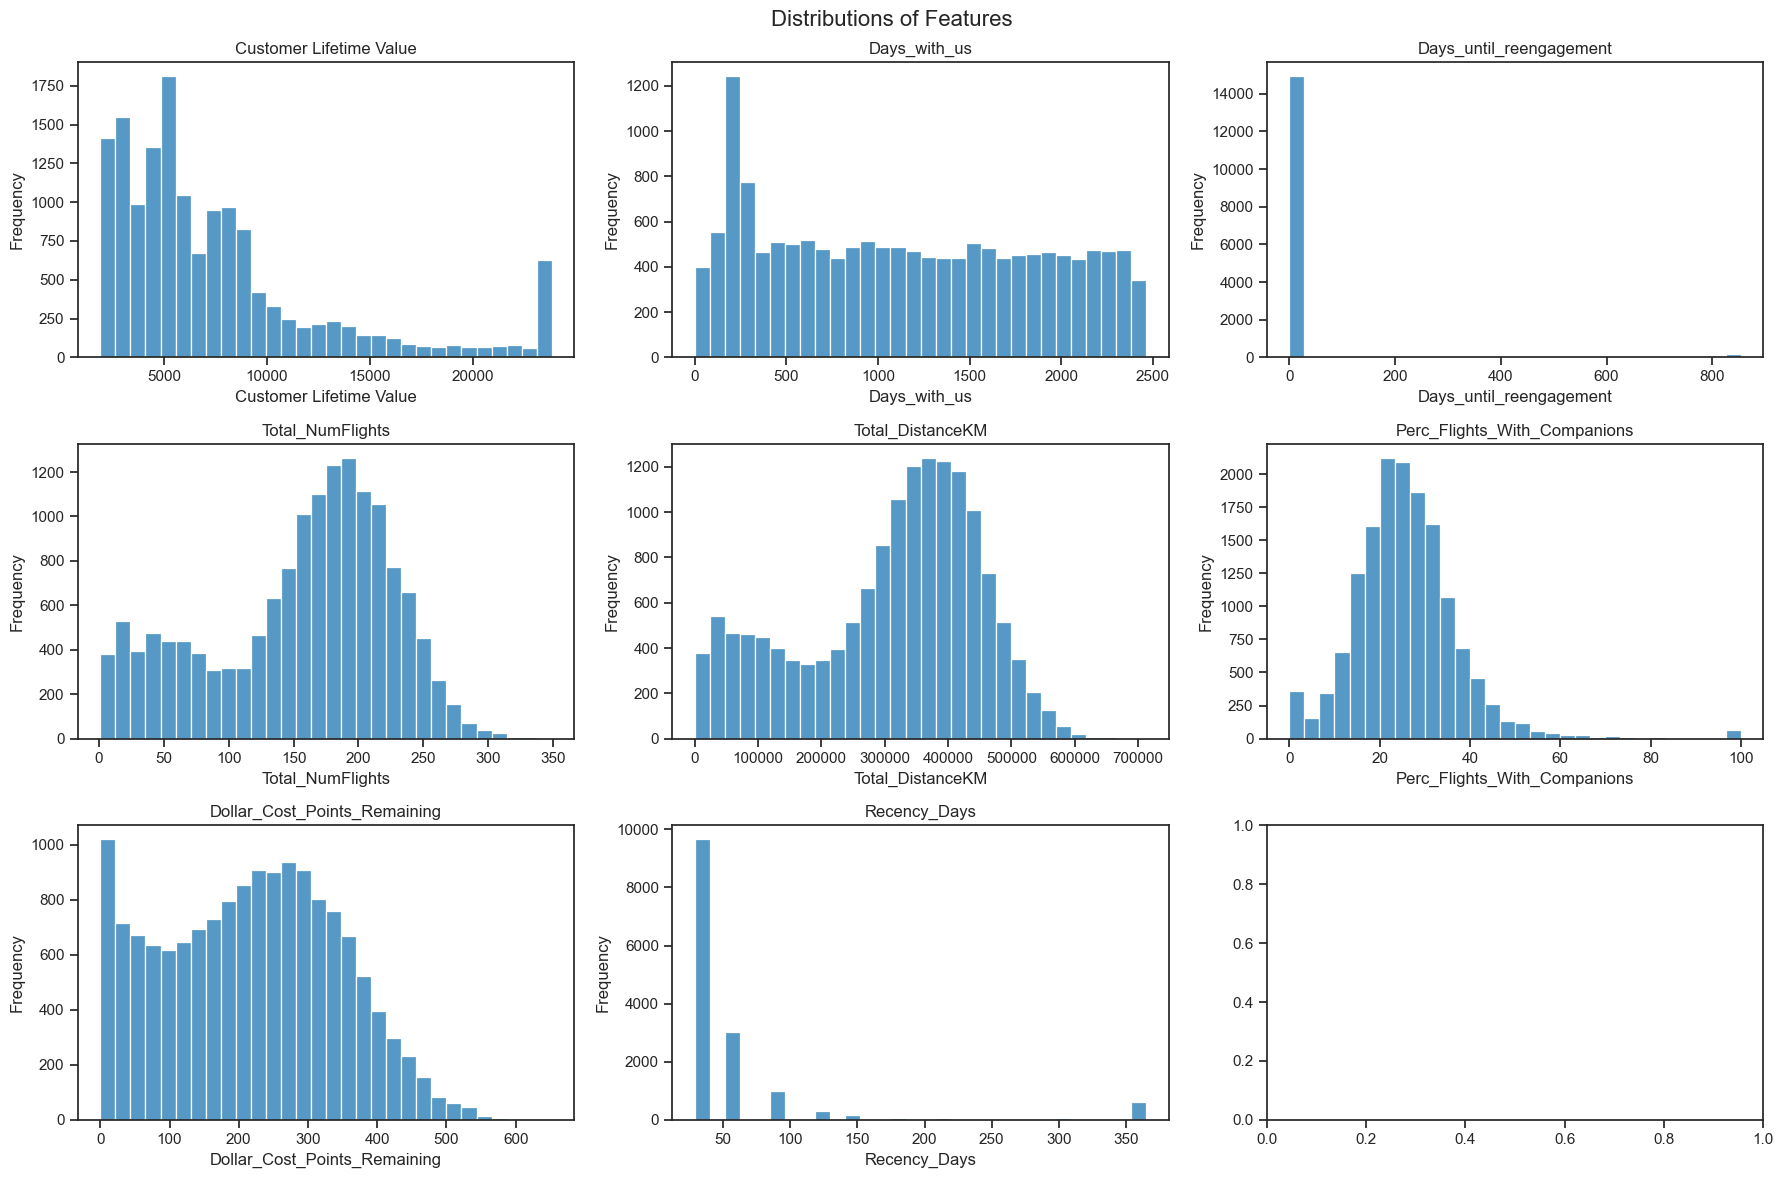

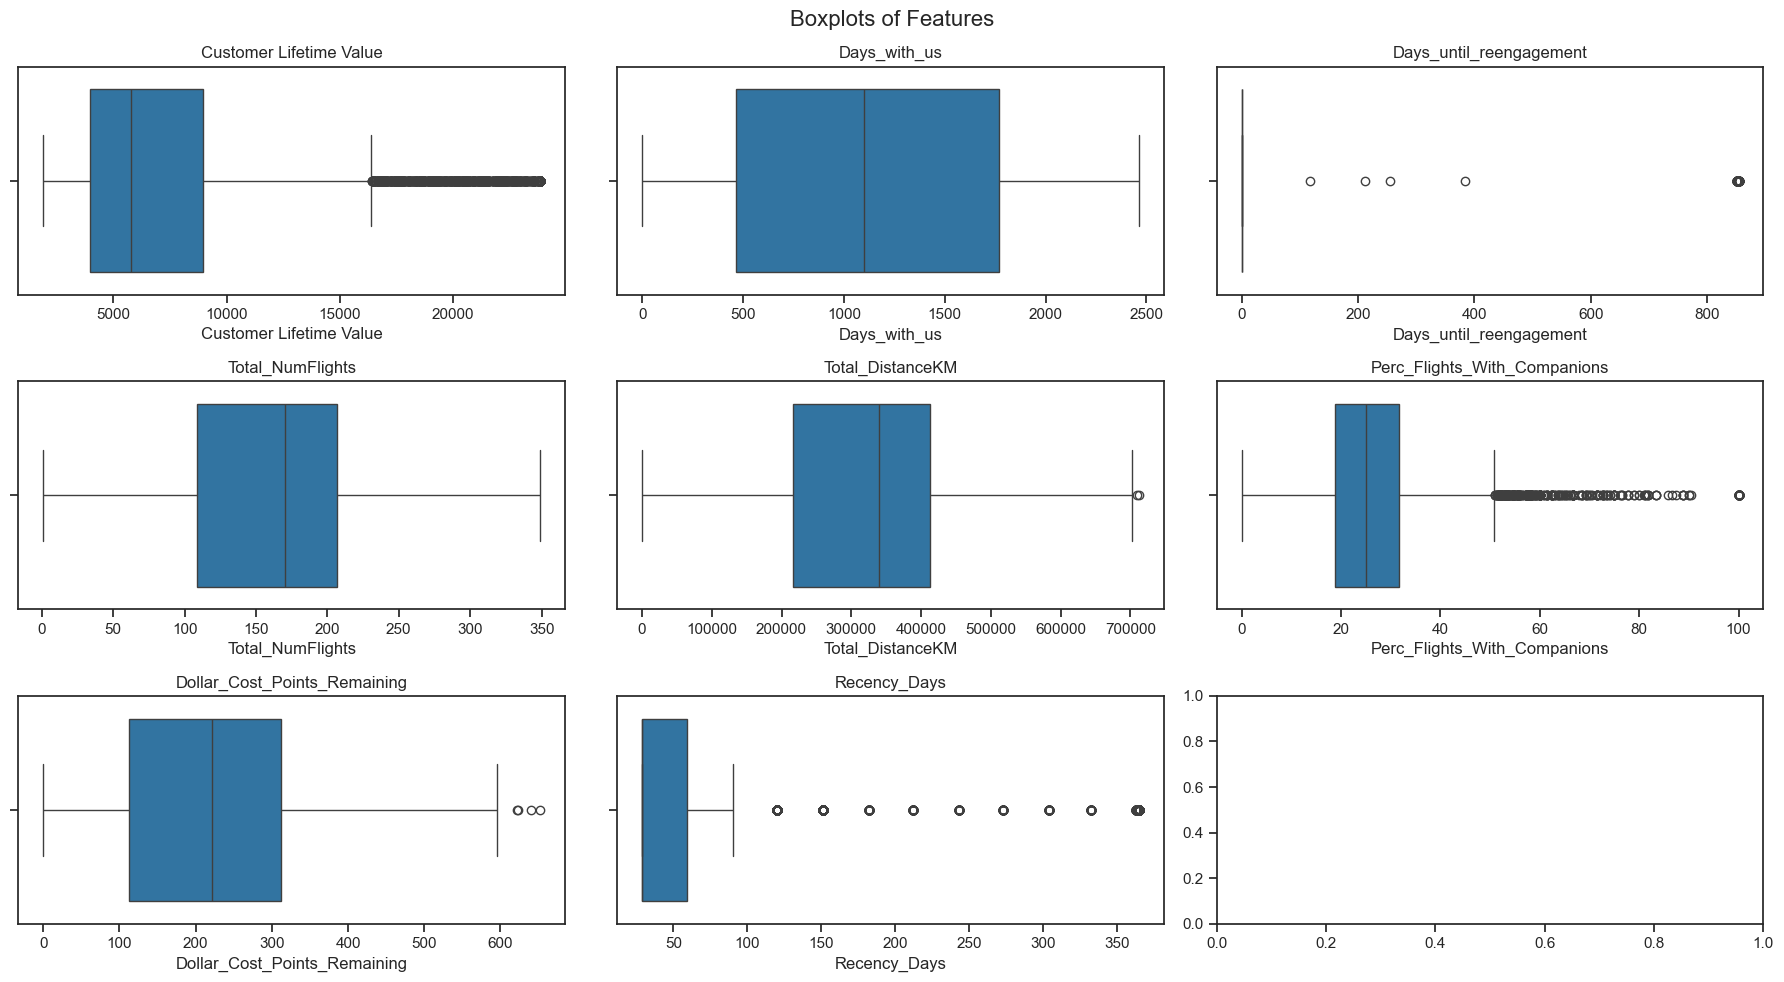

In [1155]:
cols = [
    col for col in Value_Based_Segmentation_clustering.columns
    if col != "Loyalty#"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    sns.histplot(data, bins=30, ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle(
    "Distributions of Features",
    fontsize=16
)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    data = Value_Based_Segmentation_clustering[col].dropna()
    
    sns.boxplot(x=data, ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots of Features",
    fontsize=16
)
plt.tight_layout()
plt.show()


## Scaling 

We tried using the Robust Scaler, but after examining the results in our models(K-Means in particular) we noticed that the inertia graph (used to test different values of k) looked unrealistic. So, we decided to apply Min-Max scaling from -1 to 1 for all features except Loyalty#.

In [1156]:

scaler = MinMaxScaler(feature_range=(-1, 1))

features_to_scale = [
    'Customer Lifetime Value',
    'Days_with_us',
    'Days_until_reengagement',
    'Total_NumFlights',
    'Total_DistanceKM',
    'Perc_Flights_With_Companions',
    'Dollar_Cost_Points_Remaining',
    'Recency_Days'
]

# preserve original data
Value_Based_Segmentation_clustering_scaled = Value_Based_Segmentation_clustering.copy()

# apply Min-Max scaling to [-1, 1]
Value_Based_Segmentation_clustering_scaled[features_to_scale] = scaler.fit_transform(
    Value_Based_Segmentation_clustering[features_to_scale]
)

Value_Based_Segmentation_clustering_scaled.head()


,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days
Loyalty#,,,,,,,,
480934,-0.823155,-0.148884,-1.0,0.091954,0.395288,-0.413613,0.110600,-1.000000
549612,-0.823112,-0.166734,-1.0,0.597701,0.093611,-0.770609,-0.493173,-1.000000
429460,-0.823099,0.033671,-1.0,-0.316092,-0.355997,-0.333333,-0.463387,0.988095
608370,-0.823099,0.738742,-1.0,0.120690,0.082634,-0.408163,-0.317210,-1.000000
530508,-0.822822,0.238945,-1.0,-0.022989,0.028112,-0.263158,0.124095,-1.000000


In [1157]:
Value_Based_Segmentation_clustering_scaled.describe().T


,count,mean,std,min,25%,50%,75%,max
Customer Lifetime Value,15101.0,-0.479813,0.488835,-1.0,-0.811834,-0.647183,-0.358876,1.0
Days_with_us,15101.0,-0.074112,0.586347,-1.0,-0.621907,-0.108316,0.436917,1.0
Days_until_reengagement,15101.0,-0.976844,0.213307,-1.0,-1.000000,-1.000000,-1.000000,1.0
Total_NumFlights,15101.0,-0.113630,0.406062,-1.0,-0.379310,-0.028736,0.183908,1.0
Total_DistanceKM,15101.0,-0.133762,0.395944,-1.0,-0.392354,-0.047029,0.157877,1.0
Perc_Flights_With_Companions,15101.0,-0.482632,0.238956,-1.0,-0.623188,-0.500000,-0.366120,1.0
Dollar_Cost_Points_Remaining,15101.0,-0.335751,0.391398,-1.0,-0.656215,-0.319680,-0.042712,1.0
Recency_Days,15101.0,-0.811347,0.439942,-1.0,-1.000000,-1.000000,-0.821429,1.0


# Clustering

## Our Final data set for clusting

Now droping Loyalty# for clustering

In [1158]:
# Our Final data set for clustering

# Assume transaction_cols and no_transaction_mask were defined earlier, and
# Value_Based_Segmentation_clustering already had dropna(subset=transaction_cols)

# Ensure Final_Cluster exists
if 'Final_Cluster' not in Value_Based_Segmentation_clustering:
    Value_Based_Segmentation_clustering['Final_Cluster'] = 'Unspecified'

# Label parked no-transaction rows
Value_Based_Segmentation_clustering_no_transaction['Final_Cluster'] = 'No_transactions'
print(Value_Based_Segmentation_clustering_no_transaction.shape[0])
# Reattach parked rows to the cleaned table
Value_Based_Segmentation_clustering = pd.concat(
    [Value_Based_Segmentation_clustering, Value_Based_Segmentation_clustering_no_transaction],
    axis=0
).sort_index()

# Build modelling set only from truly unclassified customers
unclassified_data = Value_Based_Segmentation_clustering[Value_Based_Segmentation_clustering.Final_Cluster == 'Unspecified']
data_for_modelling = Value_Based_Segmentation_clustering_scaled.loc[unclassified_data.index]

print('Final dataset shape:', Value_Based_Segmentation_clustering.shape)
print('No_transactions count:', (Value_Based_Segmentation_clustering.Final_Cluster == 'No_transactions').sum())
print('Unclassified (for modelling):', unclassified_data.shape)


1471
Final dataset shape: (16572, 9)
No_transactions count: 1471
Unclassified (for modelling): (15101, 9)


### Datasets Overview

Different versions of the data are used to clearly separate **model fitting**, **interpretation**, and **final analysis**.

#### `Value_Based_Segmentation_clustering_no_transaction`
Data of the customers who do not have any transactions.

---

#### `unclassified_data`
Customers whose `Final_Cluster` is `"Unspecified"`.  
This is the dataset used to explore and evaluate clustering solutions.

---

#### `data_for_modelling`
**Scaled numeric data** used to fit clustering algorithms.  
Scaling is applied only for modeling, not for interpretation.

---


## Ward Hierarchical
Ward’s method is used to explore the underlying structure. Using Euclidean distance with Ward linkage, we identify plausible ranges for the number of clusters before fixing the final choice.


In [1159]:
# Helper functions for within-cluster dispersion and variance explained
def compute_ssw(X, labels):
    'Sum of squared distances within clusters.'
    X_np = X.values
    ssw = 0.0
    for lbl in np.unique(labels):
        cluster_points = X_np[labels == lbl]
        centroid = cluster_points.mean(axis=0)
        ssw += ((cluster_points - centroid) ** 2).sum()
    return ssw


def compute_r2(X, labels):
    'Proportion of variance explained by cluster assignment.'
    X_np = X.values
    sst = ((X_np - X_np.mean(axis=0)) ** 2).sum()
    ssw = compute_ssw(X, labels)
    return 1 - ssw / sst


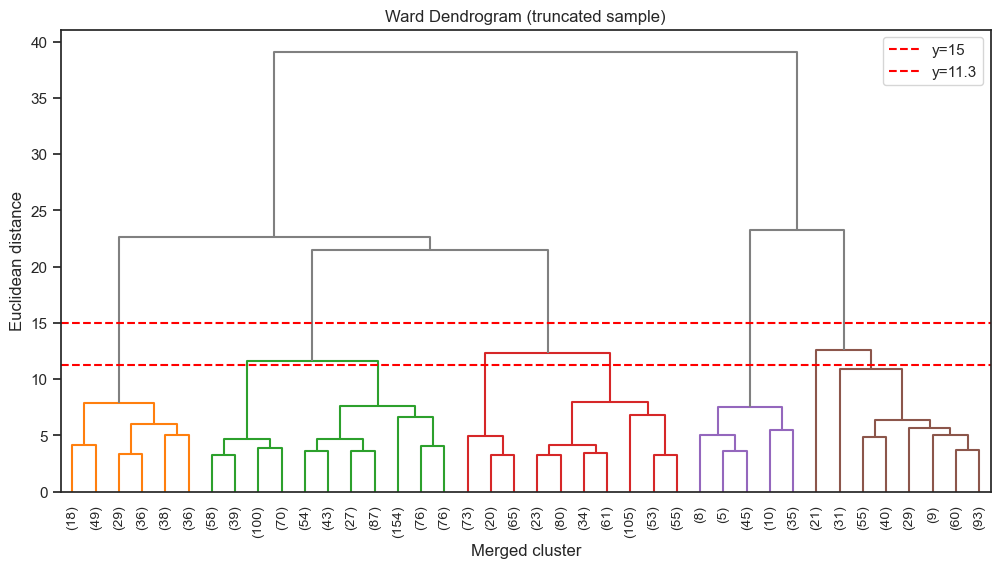

Final candidate k range (visual cut y=15, y=11.3): [5, 7]


In [1160]:

# Ward dendrogram on a manageable sample (full tree on 15k points is too heavy)
ward_sample = data_for_modelling.sample(n=min(2000, data_for_modelling.shape[0]), random_state=RANDOM_STATE)
ward_full_model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0,
    linkage='ward',
    metric='euclidean'
)
ward_full_model.fit(ward_sample)

Y_THRESHOLD = 15  # visual cut to yield ~5 clusters on the truncated tree
Y_THRESHOLD_2 = 11.3  # visual cut to yield ~ 7clusters on the truncated tree

plt.figure(figsize=(12, 6))
plot_dendrogram(
    ward_full_model,
    truncate_mode="lastp",
    p=40,
    leaf_rotation=90.,
    leaf_font_size=10.,
    color_threshold=Y_THRESHOLD,
    above_threshold_color='gray'
)
plt.axhline(y=Y_THRESHOLD, color='red', linestyle='--', label=f'y={Y_THRESHOLD}')
plt.axhline(y=Y_THRESHOLD_2, color='red', linestyle='--', label=f'y={Y_THRESHOLD_2}')

plt.legend(loc='upper right')
plt.title("Ward Dendrogram (truncated sample)")
plt.xlabel("Merged cluster")
plt.ylabel("Euclidean distance")
plt.show()

# Visually preferred ks from dendrogram cut
candidate_k_range = [5, 7]
print(f"Final candidate k range (visual cut y={Y_THRESHOLD}, y={Y_THRESHOLD_2}): {candidate_k_range}")


**Dendrogram conclusion:** Using a visual cut at y ≈ 15 and 11 on the Ward tree, we carry forward candidate k values **5** and **7** for Ward evaluation.

In [1161]:
ks = range(2, 11)  # Ward cluster counts to evaluate

ward_metrics = []
X = data_for_modelling.values
sst = ((X - X.mean(axis=0)) ** 2).sum()

for k in ks:
    ward = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = ward.fit_predict(data_for_modelling)
    counts = pd.Series(labels).value_counts().sort_index()

    ssw = compute_ssw(data_for_modelling, labels)
    ssb = sst - ssw
    r2 = 1 - ssw / sst
    sil = silhouette_score(data_for_modelling, labels)

    ward_metrics.append({
        'model': f'Ward_{k}',
        'num_clusters': k,
        'ssw (Lower is better, 0 to +∞)': ssw,
        'ssb (Higher is better, 0 to SST)': ssb,
        'r2 (Higher is better, 0 to 1)': r2,
        'silhouette_score (Higher is better, −1 to +1)': sil,
        'min_cluster_size': counts.min(),
        'max_cluster_size': counts.max(),
        'inertia': np.nan
    })

df_cluster_metrics_ward = pd.DataFrame(ward_metrics)
display(df_cluster_metrics_ward)

,model,num_clusters,"ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)","r2 (Higher is better, 0 to 1)","silhouette_score (Higher is better, −1 to +1)",min_cluster_size,max_cluster_size,inertia
0,Ward_2,2,13697.372309,6744.437816,0.329933,0.385773,3710,11391,NaN
1,Ward_3,3,11607.332337,8834.477788,0.432177,0.387406,818,11391,NaN
2,Ward_4,4,9703.666905,10738.143220,0.525303,0.313191,818,9559,NaN
3,Ward_5,5,8217.467498,12224.342627,0.598007,0.235498,818,6387,NaN
4,Ward_6,6,7555.887765,12885.922360,0.630371,0.247562,174,6387,NaN
5,Ward_7,7,6944.064774,13497.745351,0.660301,0.213959,174,3546,NaN
6,Ward_8,8,6552.158855,13889.651270,0.679473,0.203732,174,3546,NaN
7,Ward_9,9,6207.051825,14234.758300,0.696355,0.180278,174,3172,NaN
8,Ward_10,10,5905.414565,14536.395559,0.711111,0.179077,174,3172,NaN


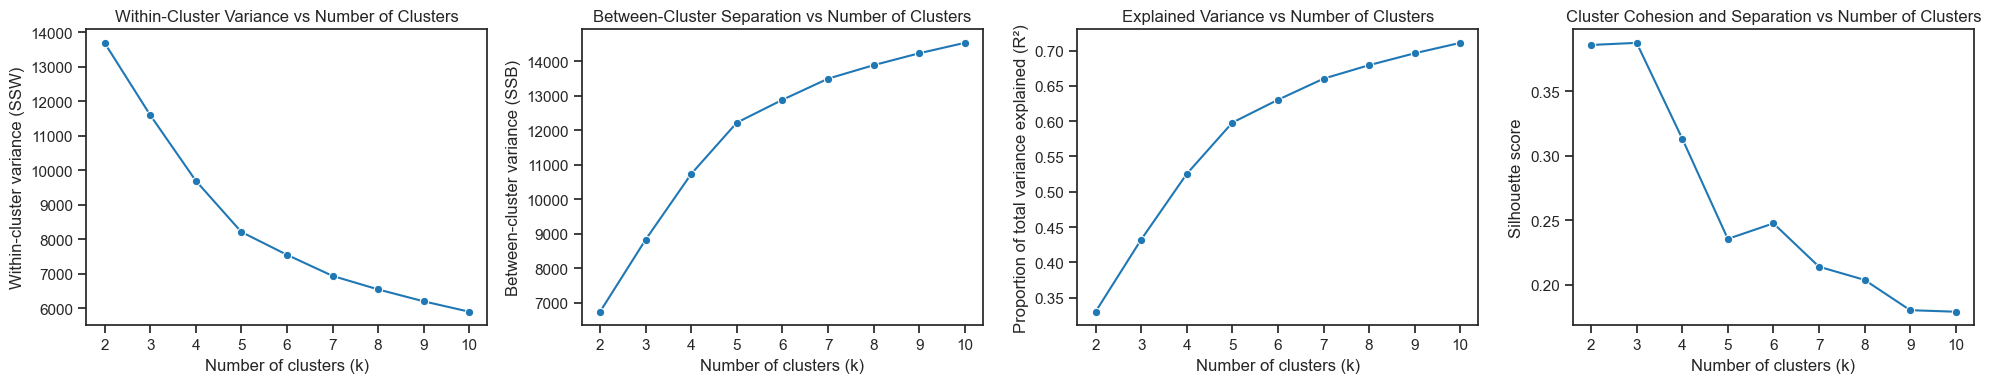

In [1162]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
ax1, ax2, ax3, ax4 = axes

sns.lineplot(
    data=df_cluster_metrics_ward,  # or combined DF
    x='num_clusters',
    y='ssw (Lower is better, 0 to +∞)',
    marker='o',
    ax=ax1
)
ax1.set(
    title='Within-Cluster Variance vs Number of Clusters',
    xlabel='Number of clusters (k)',
    ylabel='Within-cluster variance (SSW)'
)
ax1.set_xticks(df_cluster_metrics_ward['num_clusters'])

sns.lineplot(
    data=df_cluster_metrics_ward,
    x='num_clusters',
    y='ssb (Higher is better, 0 to SST)',
    marker='o',
    ax=ax2
)
ax2.set(
    title='Between-Cluster Separation vs Number of Clusters',
    xlabel='Number of clusters (k)',
    ylabel='Between-cluster variance (SSB)'
)
ax2.set_xticks(df_cluster_metrics_ward['num_clusters'])

sns.lineplot(
    data=df_cluster_metrics_ward,
    x='num_clusters',
    y='r2 (Higher is better, 0 to 1)',
    marker='o',
    ax=ax3
)
ax3.set(
    title='Explained Variance vs Number of Clusters',
    xlabel='Number of clusters (k)',
    ylabel='Proportion of total variance explained (R²)'
)
ax3.set_xticks(df_cluster_metrics_ward['num_clusters'])

sns.lineplot(
    data=df_cluster_metrics_ward,
    x='num_clusters',
    y='silhouette_score (Higher is better, −1 to +1)',
    marker='o',
    ax=ax4
)
ax4.set(
    title='Cluster Cohesion and Separation vs Number of Clusters',
    xlabel='Number of clusters (k)',
    ylabel='Silhouette score'
)
ax4.set_xticks(df_cluster_metrics_ward['num_clusters'])

plt.tight_layout()
plt.show()


### Ward (k = 5)

In [1163]:
# Ward solution with 5 cluster
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=5)
hc_labels = hclust.fit_predict(data_for_modelling)
hc_labels

array([1, 1, 1, ..., 3, 0, 4])

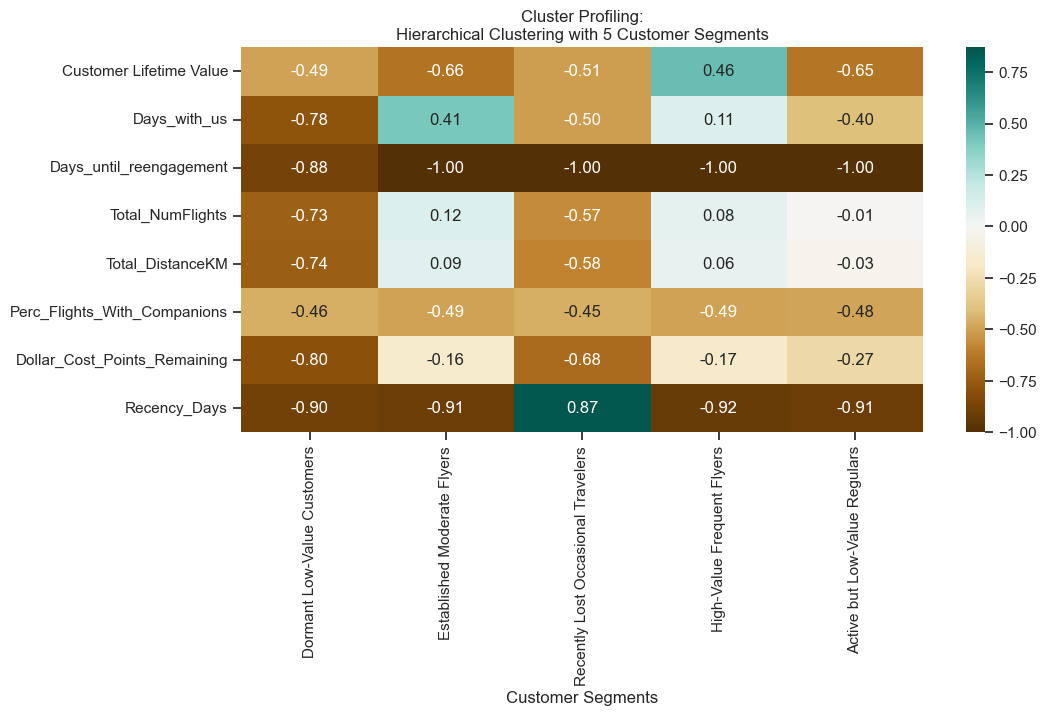

In [1164]:
cluster_name_map_5 = {
    0: "Dormant Low-Value Customers",
    1: "Established Moderate Flyers",
    2: "Recently Lost Occasional Travelers",
    3: "High-Value Frequent Flyers",
    4: "Active but Low-Value Regulars"
}
df_concat_hc_5 = pd.concat(
    (data_for_modelling, pd.Series(hc_labels, name='labels', index=data_for_modelling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(11, 5))

hc_profile_5 = df_concat_hc_5.groupby('labels').mean().T

# Rename cluster columns with descriptive names
hc_profile_5 = hc_profile_5.rename(columns=cluster_name_map_5)

sns.heatmap(
    hc_profile_5,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nHierarchical Clustering with 5 Customer Segments")
plt.show()
df_concat_hc_5['cluster_name'] = df_concat_hc_5['labels'].map(cluster_name_map_5)


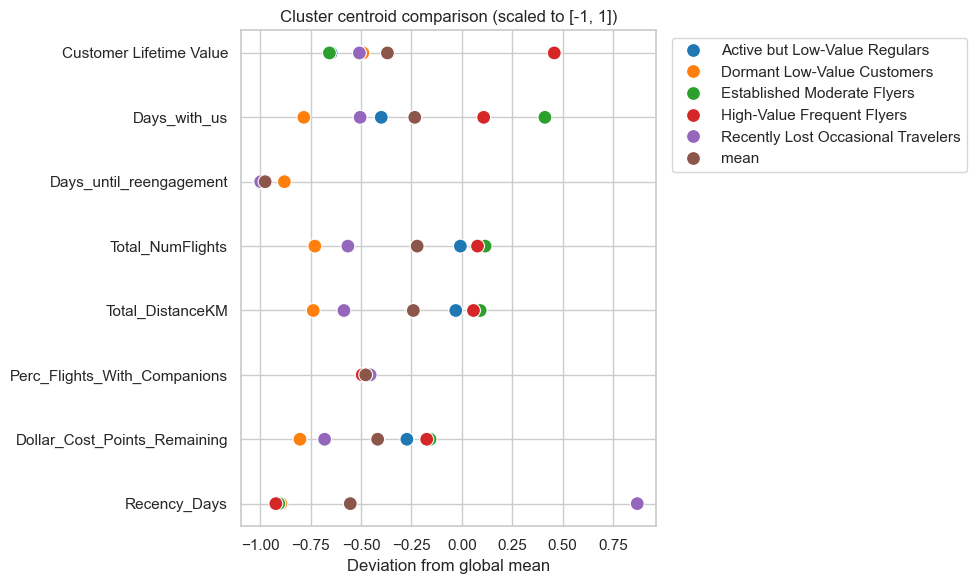

In [1165]:
# Compute centroids
centroids_df = (
    df_concat_hc_5
    .groupby('cluster_name')[data_for_modelling.columns]
    .mean()
    .reset_index()
    .rename(columns={'cluster_name': 'cluster'})
)

# Add mean row
mean_row = pd.DataFrame(
    [['mean'] + list(centroids_df.iloc[:, 1:].mean())],
    columns=centroids_df.columns
)
centroids_df = pd.concat([centroids_df, mean_row], ignore_index=True)

# Melt (NO re-scaling)
melt_data = centroids_df.melt(
    id_vars='cluster',
    var_name='variable',
    value_name='value'
)

# Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.scatterplot(
    data=melt_data,
    x='value',
    y='variable',
    hue='cluster',
    s=100
)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title("Cluster centroid comparison (scaled to [-1, 1])")
plt.xlabel("Deviation from global mean")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Cluster Interpretations for Hierarchical Clustering with 6 Clusters:**

- **Dormant Low-Value Customers** – Customers with very low engagement and long inactivity.

- **Established Moderate Flyers** – Long-tenured, active customers with modest engagement and low value.

- **Recently Lost Occasional Travelers** – Customers with limited historical value who have recently disengaged.

- **High-Value Frequent Flyers** – Your core, most valuable, and most loyal customers.

- **Active but Low-Value Regulars** – Customers who remain active but generate limited economic value.

In [1166]:
df_concat_hc_5['cluster_name'].value_counts()

cluster_name
Established Moderate Flyers           6387
Active but Low-Value Regulars         3172
Dormant Low-Value Customers           2892
High-Value Frequent Flyers            1832
Recently Lost Occasional Travelers     818
Name: count, dtype: int64

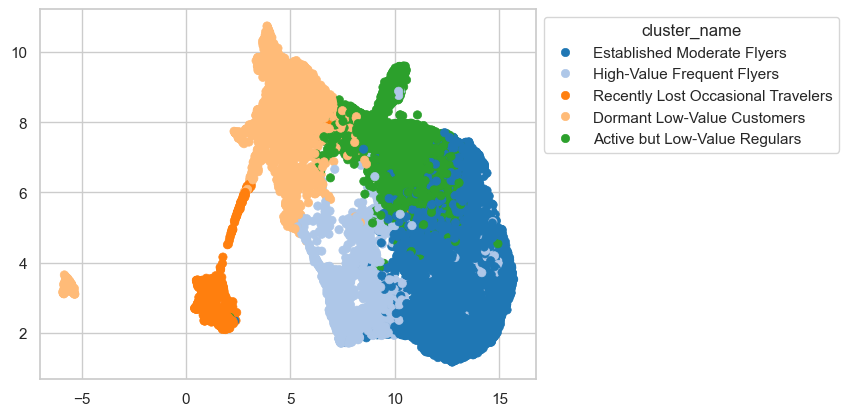

In [1167]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(data_for_modelling)
targets = df_concat_hc_5['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### Ward (k = 7)

In [1168]:
# Ward solution with 7 cluster
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=7)
hc_labels = hclust.fit_predict(data_for_modelling)
hc_labels

array([1, 1, 1, ..., 3, 0, 4])

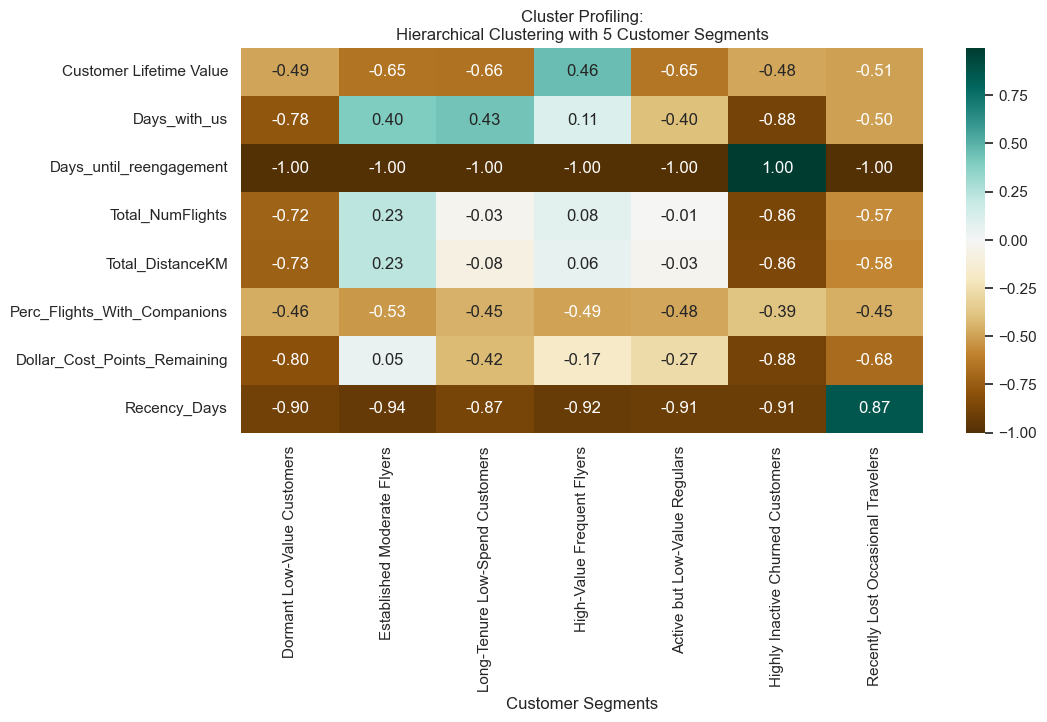

In [1169]:
cluster_name_map_hc_7 = {
    0: "Dormant Low-Value Customers",
    1: "Established Moderate Flyers",
    2: "Long-Tenure Low-Spend Customers",
    3: "High-Value Frequent Flyers",
    4: "Active but Low-Value Regulars",
    5: "Highly Inactive Churned Customers",
    6: "Recently Lost Occasional Travelers"
}
df_concat_hc_7 = pd.concat(
    (data_for_modelling, pd.Series(hc_labels, name='labels', index=data_for_modelling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(11, 5))

hc_profile_7 = df_concat_hc_7.groupby('labels').mean().T

# Rename cluster columns with descriptive names
hc_profile_7 = hc_profile_7.rename(columns=cluster_name_map_hc_7)

sns.heatmap(
    hc_profile_7,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nHierarchical Clustering with 5 Customer Segments")
plt.show()

df_concat_hc_7['cluster_name'] = df_concat_hc_7['labels'].map(cluster_name_map_hc_7)

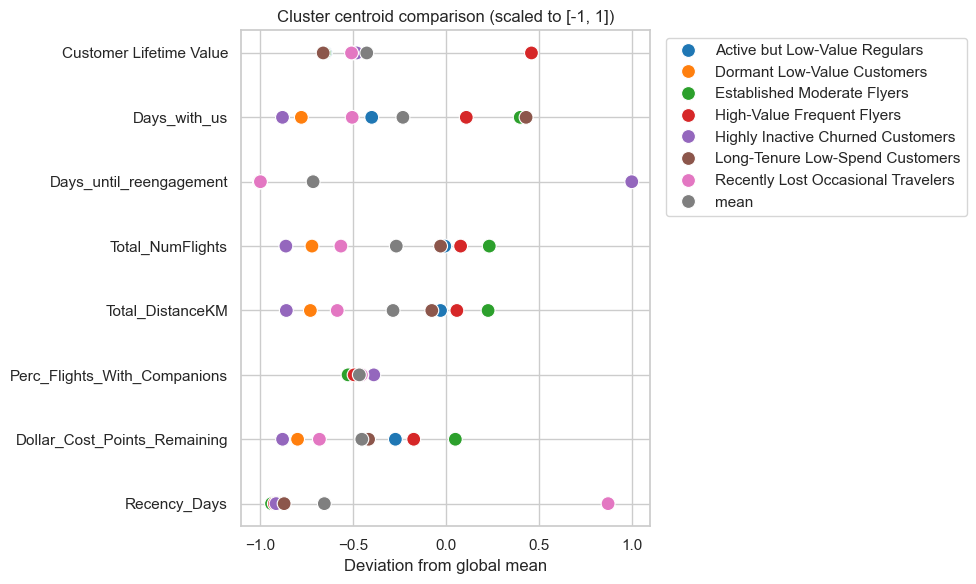

In [1170]:
# Compute centroids
centroids_df = (
    df_concat_hc_7
    .groupby('cluster_name')[data_for_modelling.columns]
    .mean()
    .reset_index()
    .rename(columns={'cluster_name': 'cluster'})
)

# Add mean row
mean_row = pd.DataFrame(
    [['mean'] + list(centroids_df.iloc[:, 1:].mean())],
    columns=centroids_df.columns
)
centroids_df = pd.concat([centroids_df, mean_row], ignore_index=True)

# Melt (NO re-scaling)
melt_data = centroids_df.melt(
    id_vars='cluster',
    var_name='variable',
    value_name='value'
)

# Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.scatterplot(
    data=melt_data,
    x='value',
    y='variable',
    hue='cluster',
    s=100
)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title("Cluster centroid comparison (scaled to [-1, 1])")
plt.xlabel("Deviation from global mean")
plt.ylabel("")
plt.tight_layout()
plt.show()

- **0 - Dormant Low-Value Customers** – Very inactive customers with weak historical engagement.

- **1 - Established Moderate Flyers** – Longer-tenured customers with moderate engagement but limited value.  
  *Stable engagement but moderate spend; potential for upsell or retention programs.*

- **2 - Long-Tenure Low-Spend Customers** – Customers who stay enrolled but do not translate tenure into value.  
  *Long-standing but low-value; ideal for targeted monetization strategies.*

- **3 - High-Value Frequent Flyers** – Your most valuable and strategically important segment.  
  *Highly loyal, high-frequency customers — prioritize retention and rewards.*

- **4 - Active but Low-Value Regulars** – Recently active customers whose activity does not generate value.  
  *Frequent but low-spend; opportunity for upsell and loyalty incentives.*

- **5 - Highly Inactive Churned Customers** – Customers showing the strongest churn signals.  
  *Very low engagement; focus on reactivation campaigns if worthwhile.*

- **6 - Recently Lost Occasional Travelers** – Customers with past activity who have recently disengaged.  
  *Previously engaged but recently dormant — prime reactivation candidates.*

In [1171]:
df_concat_hc_7['cluster_name'].value_counts()

cluster_name
Established Moderate Flyers           3546
Active but Low-Value Regulars         3172
Long-Tenure Low-Spend Customers       2841
Dormant Low-Value Customers           2718
High-Value Frequent Flyers            1832
Recently Lost Occasional Travelers     818
Highly Inactive Churned Customers      174
Name: count, dtype: int64

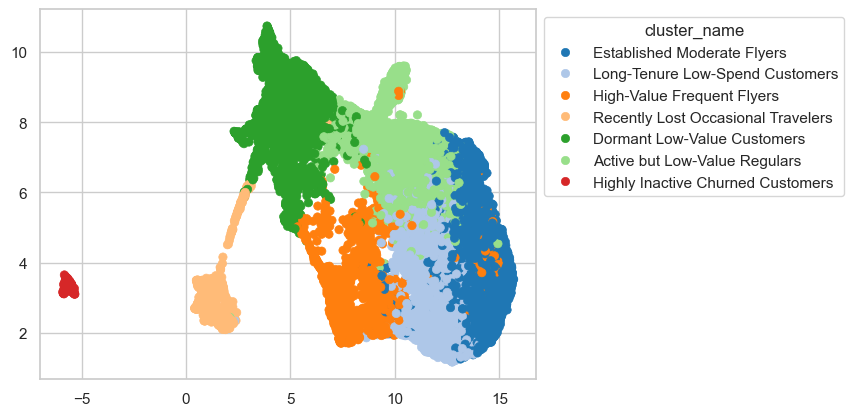

In [1172]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(data_for_modelling)
targets = df_concat_hc_7['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## K-Means
Apply K-Means with extensive initialization, evaluate the results quantitatively, and then select the final model by balancing inertia, R², silhouette scores, and cluster size distribution.

In [1173]:
X = data_for_modelling.values

# Compute SST once (constant for all clusterings)
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)

results = []

for n_clusters in range(2, 11):  # Test from 2 to 10 clusters
    kmclust = KMeans(n_clusters=n_clusters, init='k-means++', random_state=22)
    labels = kmclust.fit_predict(data_for_modelling)
    
    # ---- SSW ----
    ssw = kmclust.inertia_
    
    # ---- SSB ----
    ssb_iter = []
    for i in np.unique(labels):
        X_k = X[labels == i]
        ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))
    ssb_per_feature = np.sum(ssb_iter, axis=0)
    ssb = np.sum(ssb_per_feature, axis=0)
    
    # ---- Silhouette ----
    sil_score = silhouette_score(X, labels)
    
    results.append({
        'num_clusters': n_clusters,
        'ssw (Lower is better, 0 to +∞)': ssw,
        'ssb (Higher is better, 0 to SST)': ssb,
        'silhouette_score (Higher is better, −1 to +1)': sil_score,
        'r2 (Higher is better, 0 to 1)': ssb / sst,
        
        
    })

df_cluster_metrics = pd.DataFrame(results)

In [1174]:
df_cluster_metrics

,num_clusters,"ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)","silhouette_score (Higher is better, −1 to +1)","r2 (Higher is better, 0 to 1)"
0,2,13278.963583,7162.849631,0.371533,0.350402
1,3,11432.778908,9009.049377,0.225013,0.440717
2,4,9687.692123,10754.120097,0.246920,0.526085
3,5,9120.805925,11321.045180,0.188525,0.553818
4,6,7099.304829,13342.544617,0.236103,0.652709
5,7,6654.947737,13786.873481,0.211302,0.674445
6,8,5957.548430,14484.312825,0.253790,0.708563
7,9,5525.746449,14916.077092,0.234027,0.729685
8,10,5319.091709,15122.725894,0.229096,0.739794


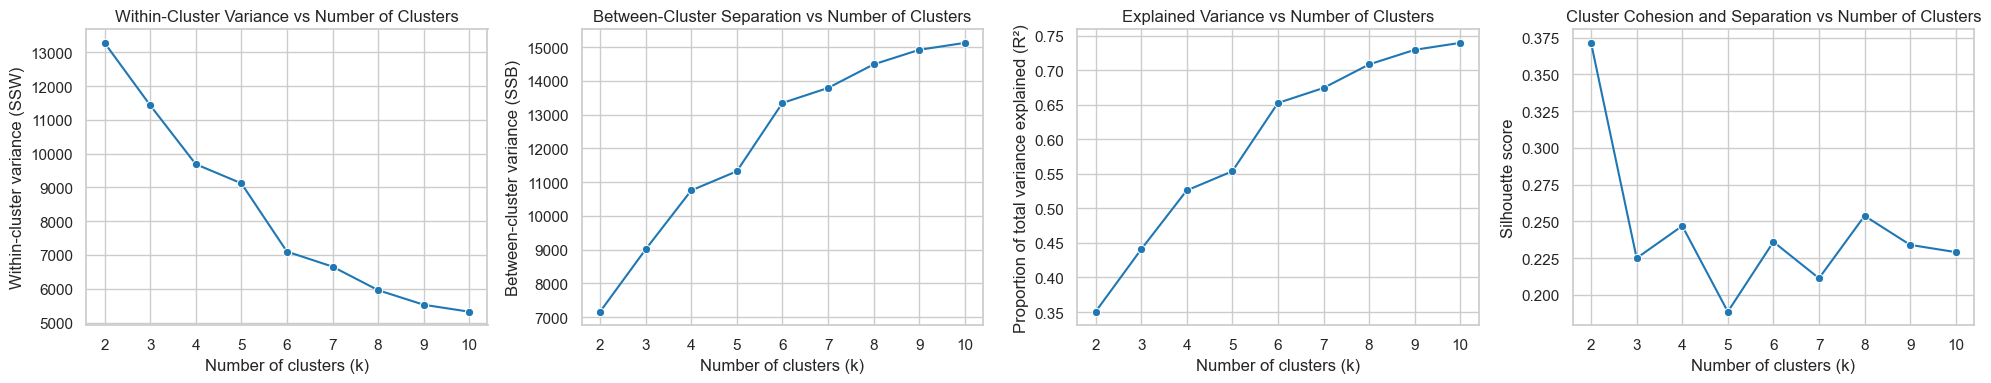

In [1175]:
# Plotting the clustering metrics
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
ax1, ax2, ax3, ax4 = axes

# ---- SSW (Within-cluster variance) ----
sns.lineplot(
    data=df_cluster_metrics,
    x='num_clusters',
    y='ssw (Lower is better, 0 to +∞)',
    marker='o',
    ax=ax1
)
ax1.set(
    title='Within-Cluster Variance vs Number of Clusters',
    xlabel='Number of clusters (k)',
    ylabel='Within-cluster variance (SSW)'
)
ax1.set_xticks(df_cluster_metrics['num_clusters'])

# ---- SSB (Between-cluster variance) ----
sns.lineplot(
    data=df_cluster_metrics,
    x='num_clusters',
    y='ssb (Higher is better, 0 to SST)',
    marker='o',
    ax=ax2
)
ax2.set(
    title='Between-Cluster Separation vs Number of Clusters',
    xlabel='Number of clusters (k)',
    ylabel='Between-cluster variance (SSB)'
)
ax2.set_xticks(df_cluster_metrics['num_clusters'])

# ---- R² (Explained variance) ----
sns.lineplot(
    data=df_cluster_metrics,
    x='num_clusters',
    y='r2 (Higher is better, 0 to 1)',
    marker='o',
    ax=ax3
)
ax3.set(
    title='Explained Variance vs Number of Clusters',
    xlabel='Number of clusters (k)',
    ylabel='Proportion of total variance explained (R²)'
)
ax3.set_xticks(df_cluster_metrics['num_clusters'])

# ---- Silhouette score ----
sns.lineplot(
    data=df_cluster_metrics,
    x='num_clusters',
    y='silhouette_score (Higher is better, −1 to +1)',
    marker='o',
    ax=ax4
)
ax4.set(
    title='Cluster Cohesion and Separation vs Number of Clusters',
    xlabel='Number of clusters (k)',
    ylabel='Silhouette score'
)
ax4.set_xticks(df_cluster_metrics['num_clusters'])

plt.tight_layout()
plt.show()


Based on the results from the clustering metrics table, we are going to choose 5 and 8 clusters to create the segments. 

For 5 clusters:
- Silhouette Score: ~0.29
- R²: ~0.63 (explains 63% of variance)
- Provides a balanced number of segments for interpretation.

For 8 clusters:
- Silhouette Score: ~0.22
- R²: ~0.70 
- Offers more granularity for detailed customer segmentation.

We selected both (5 and 8) to compare their profiling.

### K-mean (k = 5)

In [1176]:
# K mean solution with 5 cluster
number_clusters = 5
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(data_for_modelling)
km_labels

array([3, 2, 3, ..., 4, 1, 0], dtype=int32)

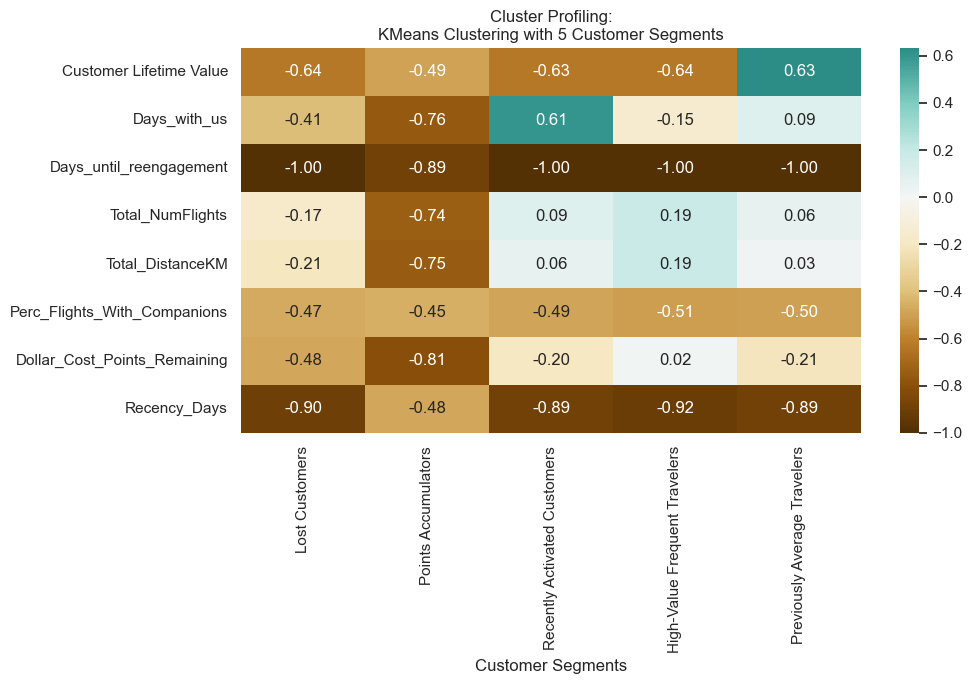

In [1177]:
cluster_name_map_5 = {
    0: "Lost Customers",
    1: "Points Accumulators",
    2: "Recently Activated Customers",
    3: "High-Value Frequent Travelers",
    4: "Previously Average Travelers"
}


df_concat_km5 = pd.concat(
    (data_for_modelling, pd.Series(km_labels, name='labels', index=data_for_modelling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 5))

# Compute cluster profiles
km_profile = df_concat_km5.groupby('labels').mean().T

# Rename cluster columns using your mapping
km_profile = km_profile.rename(columns=cluster_name_map_5)

sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 5 Customer Segments")
plt.show()

df_concat_km5['cluster_name'] = df_concat_km5['labels'].map(cluster_name_map_5)

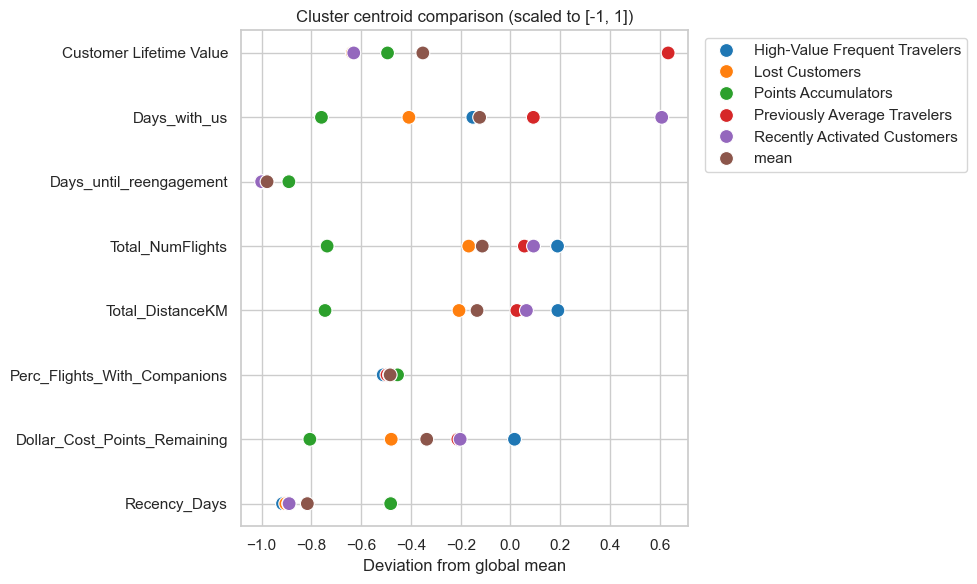

In [1178]:
# Compute centroids
centroids_df = (
    df_concat_km5
    .groupby('cluster_name')[data_for_modelling.columns]
    .mean()
    .reset_index()
    .rename(columns={'cluster_name': 'cluster'})
)

# Add mean row
mean_row = pd.DataFrame(
    [['mean'] + list(centroids_df.iloc[:, 1:].mean())],
    columns=centroids_df.columns
)
centroids_df = pd.concat([centroids_df, mean_row], ignore_index=True)

# Melt (NO re-scaling)
melt_data = centroids_df.melt(
    id_vars='cluster',
    var_name='variable',
    value_name='value'
)

# Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.scatterplot(
    data=melt_data,
    x='value',
    y='variable',
    hue='cluster',
    s=100
)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title("Cluster centroid comparison (scaled to [-1, 1])")
plt.xlabel("Deviation from global mean")
plt.ylabel("")
plt.tight_layout()
plt.show()


**Cluster Interpretations for KMeans with 5 Clusters:**

- **Lost Customers** – Previously engaged customers who now exhibit low activity and long inactivity periods, indicating churn or near-churn behavior.

- **Points Accumulators** – Long-tenured customers with steady but moderate travel activity, gradually accumulating loyalty points despite relatively low overall value.

- **Recently Activated Customers** – Customers who have become active recently after limited prior engagement, representing early-stage or reactivated travelers.

- **High-Value Frequent Travelers** – Highly engaged, frequent flyers with strong lifetime value and consistent recent activity, forming the core revenue-driving segment.

- **Previously Average Travelers** – Customers who were formerly moderate travelers but have reduced engagement, maintaining activity without corresponding value growth.

In [1179]:
df_concat_km5['cluster_name'].value_counts()

cluster_name
Recently Activated Customers     4550
Points Accumulators              3195
High-Value Frequent Travelers    3140
Lost Customers                   2740
Previously Average Travelers     1476
Name: count, dtype: int64

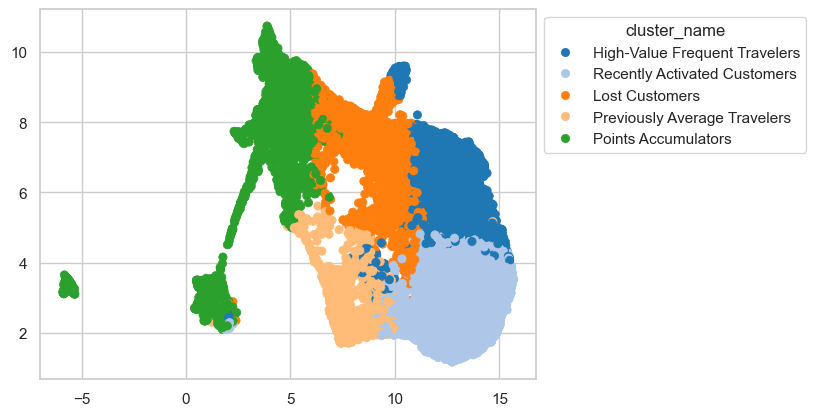

In [1180]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(data_for_modelling)
targets = df_concat_km5['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### K-mean (k = 8)

In [1181]:
# K mean solution with 8 cluster
number_clusters = 8
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(data_for_modelling)
km_labels

array([5, 2, 5, ..., 4, 1, 0], dtype=int32)

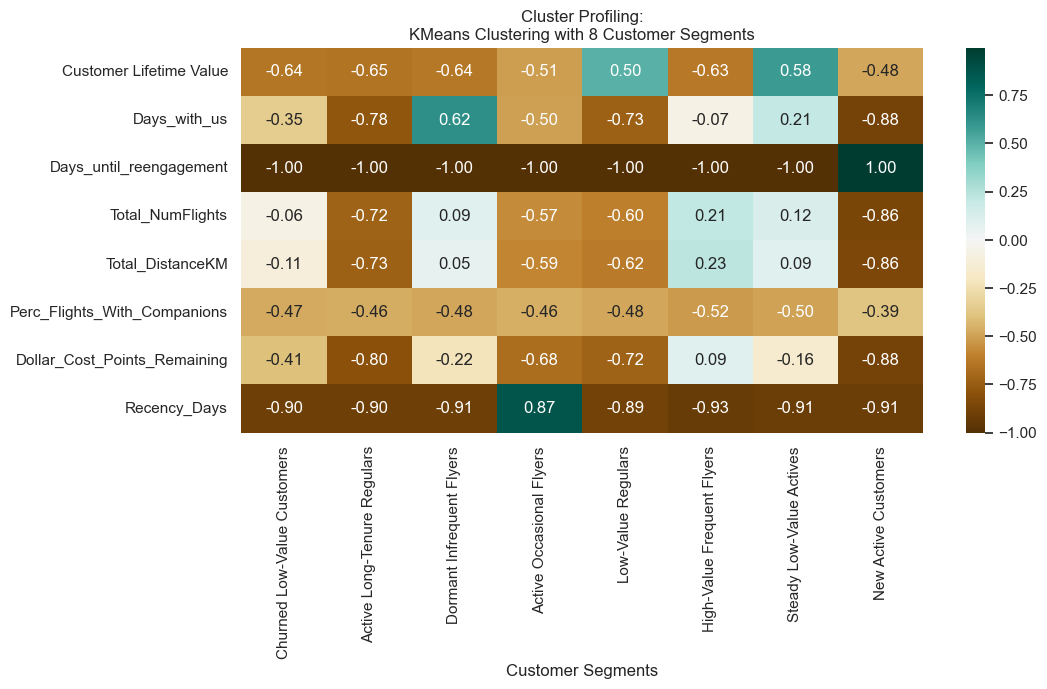

In [1198]:
cluster_name_map_8 = {
    0: "Churned Low-Value Customers",
    1: "Active Long-Tenure Regulars",
    2: "Dormant Infrequent Flyers",
    3: "Active Occasional Flyers",
    4: "Low-Value Regulars",
    5: "High-Value Frequent Flyers",
    6: "Steady Low-Value Actives",
    7: "New Active Customers"
}

df_concat_km8 = pd.concat(
    (data_for_modelling, pd.Series(km_labels, name='labels', index=data_for_modelling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(11, 5))

km_profile = df_concat_km8.groupby('labels').mean().T

# Rename cluster columns
km_profile = km_profile.rename(columns=cluster_name_map_8)

sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 8 Customer Segments")
plt.show()

df_concat_km8['cluster_name'] = df_concat_km8['labels'].map(cluster_name_map_8)

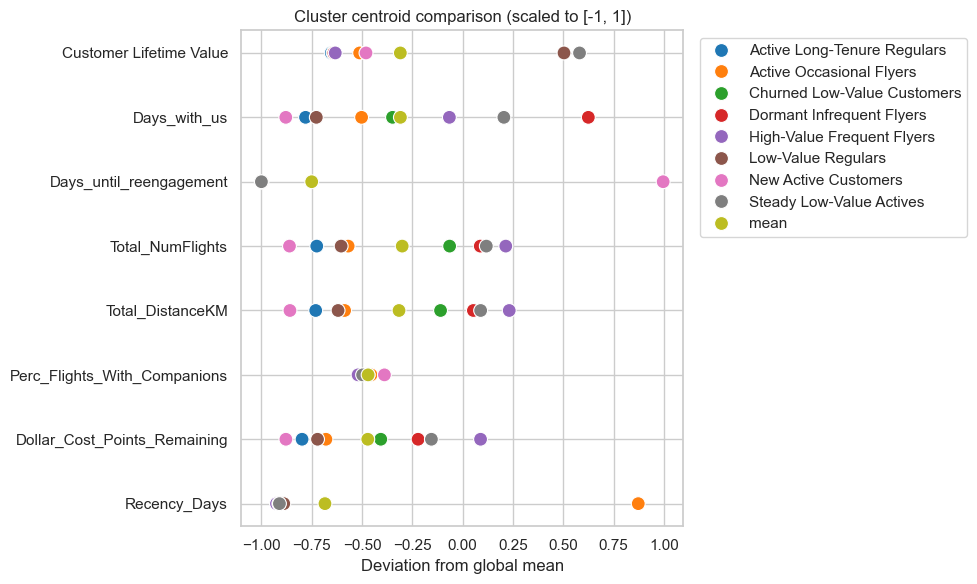

In [1183]:
# Compute centroids
centroids_df = (
    df_concat_km8
    .groupby('cluster_name')[data_for_modelling.columns]
    .mean()
    .reset_index()
    .rename(columns={'cluster_name': 'cluster'})
)

# Add mean row
mean_row = pd.DataFrame(
    [['mean'] + list(centroids_df.iloc[:, 1:].mean())],
    columns=centroids_df.columns
)
centroids_df = pd.concat([centroids_df, mean_row], ignore_index=True)

# Melt (NO re-scaling)
melt_data = centroids_df.melt(
    id_vars='cluster',
    var_name='variable',
    value_name='value'
)

# Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.scatterplot(
    data=melt_data,
    x='value',
    y='variable',
    hue='cluster',
    s=100
)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title("Cluster centroid comparison (scaled to [-1, 1])")
plt.xlabel("Deviation from global mean")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Cluster Interpretations for KMeans with 8 Clusters:**

- **Churned Low-Value Customers** – Customers with weak engagement who are currently inactive.

- **Active Long-Tenure Regulars** – Recently active, long-term customers with moderate engagement.

- **Dormant Infrequent Flyers** – Customers with low activity and long inactivity periods.

- **Active Occasional Flyers** – Recently active customers with moderate but inconsistent flying behavior.

- **Low-Value Regulars** – Consistently active but economically weak customers.

- **High-Value Frequent Flyers** – Your most valuable and loyal customer segment.

- **Steady Low-Value Actives** – Customers who remain active but contribute limited value.

- **New Active Customers** – Early-stage customers who are active but not yet valuable.


In [1184]:
df_concat_km8['cluster_name'].value_counts()

cluster_name
Dormant Infrequent Flyers      4162
Churned Low-Value Customers    3006
High-Value Frequent Flyers     2706
Active Long-Tenure Regulars    2312
Steady Low-Value Actives       1365
Active Occasional Flyers        817
Low-Value Regulars              559
New Active Customers            174
Name: count, dtype: int64

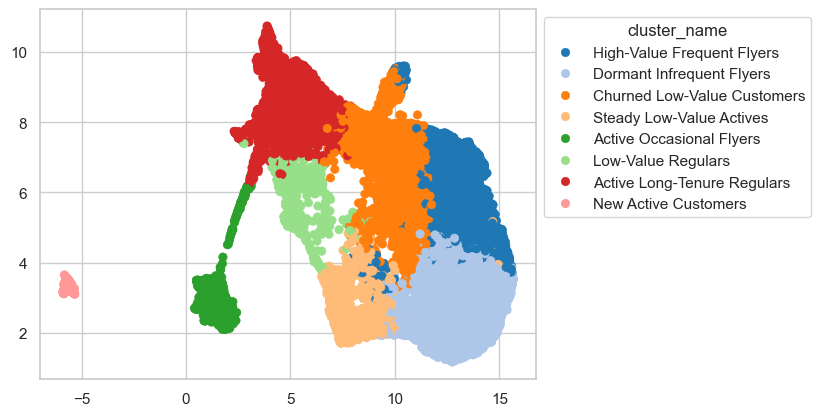

In [1185]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(data_for_modelling)
targets = df_concat_km8['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## Comparisons

In this section, we compare four approaches: K-Means with 5 clusters, K-Means with 8 clusters, Ward’s method with 5 clusters, and Ward’s method with 7 clusters. The evaluation emphasizes explained variance (R²), silhouette scores, and the balance of cluster sizes to assess both the quality of the segmentation and its interpretability.


In [1186]:
# Compare metrics between KMeans and Hierarchical Clustering
df_kmeans_selection = df_cluster_metrics.iloc[[3, 6]].copy()
df_kmeans_selection['Method'] = 'KMeans'
ward_selection = df_cluster_metrics_ward.iloc[[3, 5]].copy()
ward_selection['Method'] = 'Hierarchical'
df_final_comparison = pd.concat([df_kmeans_selection, ward_selection], ignore_index=True)

column_order = [
    'Method', 
    'num_clusters', 
    'r2 (Higher is better, 0 to 1)', 
    'silhouette_score (Higher is better, −1 to +1)',
    'ssw (Lower is better, 0 to +∞)',
    'ssb (Higher is better, 0 to SST)'
]

df_final_comparison = df_final_comparison[column_order]
display(df_final_comparison)

,Method,num_clusters,"r2 (Higher is better, 0 to 1)","silhouette_score (Higher is better, −1 to +1)","ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)"
0,KMeans,5,0.553818,0.188525,9120.805925,11321.045180
1,KMeans,8,0.708563,0.253790,5957.548430,14484.312825
2,Hierarchical,5,0.598007,0.235498,8217.467498,12224.342627
3,Hierarchical,7,0.660301,0.213959,6944.064774,13497.745351


In [1187]:
#  Create the Comparison DataFrame
df_comparison = pd.DataFrame({
    'Hierarchical_5': df_concat_hc_5['cluster_name'],
    'Hierarchical_7': df_concat_hc_7['cluster_name'],
    'KMeans_5': df_concat_km5['cluster_name'],
    'KMeans_8': df_concat_km8['cluster_name']
}, index= data_for_modelling.index)


#  Create the Grouped Comparison Table
#clustering_comparison = df_comparison.groupby(['Hierarchical', 'KMeans_5', 'KMeans_8']).size().reset_index(name='Count')

clustering_comparison1 = df_comparison.groupby([ 'KMeans_5', 'KMeans_8']).size().reset_index(name='Count')
display(clustering_comparison1.set_index(['KMeans_5', 'KMeans_8']))

clustering_comparison2 = df_comparison.groupby([ 'KMeans_5', 'Hierarchical_5']).size().reset_index(name='Count')
display(clustering_comparison2.set_index(['KMeans_5', 'Hierarchical_5']))

clustering_comparison3 = df_comparison.groupby([ 'KMeans_8', 'Hierarchical_7']).size().reset_index(name='Count')
display(clustering_comparison3.set_index(['KMeans_8', 'Hierarchical_7']))

Count
KMeans_5                      KMeans_8                          
High-Value Frequent Travelers Active Occasional Flyers         8
                              Churned Low-Value Customers    635
                              Dormant Infrequent Flyers        5
                              High-Value Frequent Flyers    2474
                              Steady Low-Value Actives        18
Lost Customers                Active Long-Tenure Regulars    366
                              Active Occasional Flyers        20
                              Churned Low-Value Customers   2293
                              Dormant Infrequent Flyers        4
                              Low-Value Regulars              57
Points Accumulators           Active Long-Tenure Regulars   1946
                              Active Occasional Flyers       731
                              Churned Low-Value Customers      5
                              Low-Value Regulars             339
                              New Active Customers           174
Previously Average Travelers  Active Occasional Flyers        14
                              Churned Low-Value Customers     16
                              Low-Value Regulars             163
                              Steady Low-Value Actives      1283
Recently Activated Customers  Active Occasional Flyers        44
                              Churned Low-Value Customers     57
                              Dormant Infrequent Flyers     4153
                              High-Value Frequent Flyers     232
                              Steady Low-Value Actives        64

Count
KMeans_5                      Hierarchical_5                           
High-Value Frequent Travelers Active but Low-Value Regulars        1383
                              Established Moderate Flyers          1629
                              High-Value Frequent Flyers            122
                              Recently Lost Occasional Travelers      6
Lost Customers                Active but Low-Value Regulars        1773
                              Dormant Low-Value Customers           399
                              Established Moderate Flyers           412
                              High-Value Frequent Flyers            134
                              Recently Lost Occasional Travelers     22
Points Accumulators           Active but Low-Value Regulars           6
                              Dormant Low-Value Customers          2456
                              Established Moderate Flyers             1
                              High-Value Frequent Flyers              1
                              Recently Lost Occasional Travelers    731
Previously Average Travelers  Active but Low-Value Regulars           4
                              Dormant Low-Value Customers            37
                              Established Moderate Flyers            56
                              High-Value Frequent Flyers           1362
                              Recently Lost Occasional Travelers     17
Recently Activated Customers  Active but Low-Value Regulars           6
                              Established Moderate Flyers          4289
                              High-Value Frequent Flyers            213
                              Recently Lost Occasional Travelers     42

Count
KMeans_8                    Hierarchical_7                           
Active Long-Tenure Regulars Active but Low-Value Regulars          82
                            Dormant Low-Value Customers          2225
                            Recently Lost Occasional Travelers      5
Active Occasional Flyers    Active but Low-Value Regulars           3
                            Dormant Low-Value Customers             5
                            Long-Tenure Low-Spend Customers         4
                            Recently Lost Occasional Travelers    805
Churned Low-Value Customers Active but Low-Value Regulars        2183
                            Dormant Low-Value Customers            78
                            Established Moderate Flyers             1
                            High-Value Frequent Flyers            148
                            Long-Tenure Low-Spend Customers       591
                            Recently Lost Occasional Travelers      5
Dormant Infrequent Flyers   Active but Low-Value Regulars           6
                            Established Moderate Flyers          2032
                            High-Value Frequent Flyers            147
                            Long-Tenure Low-Spend Customers      1977
High-Value Frequent Flyers  Active but Low-Value Regulars         891
                            Established Moderate Flyers          1498
                            High-Value Frequent Flyers            104
                            Long-Tenure Low-Spend Customers       213
Low-Value Regulars          Active but Low-Value Regulars           3
                            Dormant Low-Value Customers           410
                            High-Value Frequent Flyers            145
                            Recently Lost Occasional Travelers      1
New Active Customers        Highly Inactive Churned Customers     174
Steady Low-Value Actives    Active but Low-Value Regulars           4
                            Established Moderate Flyers            15
                            High-Value Frequent Flyers           1288
                            Long-Tenure Low-Spend Customers        56
                            Recently Lost Occasional Travelers      2

Before making a final conclusion, it is also important to compare our cluster assignments with the loyalty status available in the dataset. This allows us to assess how well the clusters align with existing customer segments and validate their practical relevance.

In [1200]:
# Align raw loyalty status to the modelling index
loyalty_status = (
    MasterCustomerDB
    .set_index('Loyalty#')['LoyaltyStatus']
    .reindex(data_for_modelling.index)
)

# Assemble labels from your models
loyalty_vs_clusters = pd.DataFrame({
    'LoyaltyStatus': loyalty_status,
    'KMeans_5': df_concat_km5['cluster_name'],
    'KMeans_8': df_concat_km8['cluster_name'],
    'Ward_5': df_concat_hc_5['cluster_name'],
    'Ward_7': df_concat_hc_7['cluster_name'],
}, index=data_for_modelling.index)

# Count tables: LoyaltyStatus (rows) x cluster names (columns)
for col in ['KMeans_5', 'KMeans_8', 'Ward_5', 'Ward_7']:
    table = (
        loyalty_vs_clusters
        .groupby(['LoyaltyStatus', col])
        .size()
        .reset_index(name='Count')
        .set_index(['LoyaltyStatus', col])
    )
    print(f'\nLoyaltyStatus vs {col} (counts):')
    display(table)



LoyaltyStatus vs KMeans_5 (counts):


Count
LoyaltyStatus KMeans_5                            
Aurora        High-Value Frequent Travelers    616
              Lost Customers                   492
              Points Accumulators              647
              Previously Average Travelers     460
              Recently Activated Customers     843
Nova          High-Value Frequent Travelers   1030
              Lost Customers                   925
              Points Accumulators             1116
              Previously Average Travelers     482
              Recently Activated Customers    1548
Star          High-Value Frequent Travelers   1494
              Lost Customers                  1323
              Points Accumulators             1432
              Previously Average Travelers     534
              Recently Activated Customers    2159


LoyaltyStatus vs KMeans_8 (counts):


Count
LoyaltyStatus KMeans_8                          
Aurora        Active Long-Tenure Regulars    419
              Active Occasional Flyers       160
              Churned Low-Value Customers    558
              Dormant Infrequent Flyers      769
              High-Value Frequent Flyers     519
              Low-Value Regulars             169
              New Active Customers            34
              Steady Low-Value Actives       430
Nova          Active Long-Tenure Regulars    794
              Active Occasional Flyers       302
              Churned Low-Value Customers    987
              Dormant Infrequent Flyers     1407
              High-Value Frequent Flyers     908
              Low-Value Regulars             190
              New Active Customers            63
              Steady Low-Value Actives       450
Star          Active Long-Tenure Regulars   1099
              Active Occasional Flyers       355
              Churned Low-Value Customers   1461
              Dormant Infrequent Flyers     1986
              High-Value Frequent Flyers    1279
              Low-Value Regulars             200
              New Active Customers            77
              Steady Low-Value Actives       485


LoyaltyStatus vs Ward_5 (counts):


Count
LoyaltyStatus Ward_5                                   
Aurora        Active but Low-Value Regulars         613
              Dormant Low-Value Customers           579
              Established Moderate Flyers          1120
              High-Value Frequent Flyers            585
              Recently Lost Occasional Travelers    161
Nova          Active but Low-Value Regulars        1023
              Dormant Low-Value Customers           993
              Established Moderate Flyers          2164
              High-Value Frequent Flyers            621
              Recently Lost Occasional Travelers    300
Star          Active but Low-Value Regulars        1536
              Dormant Low-Value Customers          1320
              Established Moderate Flyers          3103
              High-Value Frequent Flyers            626
              Recently Lost Occasional Travelers    357


LoyaltyStatus vs Ward_7 (counts):


Count
LoyaltyStatus Ward_7                                   
Aurora        Active but Low-Value Regulars         613
              Dormant Low-Value Customers           545
              Established Moderate Flyers           646
              High-Value Frequent Flyers            585
              Highly Inactive Churned Customers      34
              Long-Tenure Low-Spend Customers       474
              Recently Lost Occasional Travelers    161
Nova          Active but Low-Value Regulars        1023
              Dormant Low-Value Customers           930
              Established Moderate Flyers          1220
              High-Value Frequent Flyers            621
              Highly Inactive Churned Customers      63
              Long-Tenure Low-Spend Customers       944
              Recently Lost Occasional Travelers    300
Star          Active but Low-Value Regulars        1536
              Dormant Low-Value Customers          1243
              Established Moderate Flyers          1680
              High-Value Frequent Flyers            626
              Highly Inactive Churned Customers      77
              Long-Tenure Low-Spend Customers      1423
              Recently Lost Occasional Travelers    357

#### Loyalty Status Alignment –  Conclusion

Comparing cluster assignments with existing loyalty tiers (Star > Nova > Aurora) shows that none of the unsupervised models directly replicate the loyalty segmentation, which is expected since loyalty status was not used as an input feature. Across all methods, clusters contain a mix of Aurora, Nova, and Star customers, with Star generally being the most numerous due to its higher overall representation in the dataset. 
However, **Ward hierarchical clustering (especially the 5-cluster solution)** provides very meaningful alignment from a value-based perspective: it identifies a *High-Value Frequent Flyers* cluster where Aurora and Nova customers are almost as prevalent as Star customers, revealing high-performing customers who are underrepresented in the loyalty program. This indicates that Ward clustering best complements the existing loyalty structure by uncovering “hidden high-value” customers and highlighting mismatches between current loyalty status and actual behavior, thereby offering the strongest practical validation of the segmentation. 
**K-Means with 8 clusters**  on the other hand shows a clear and intuitive monotonic pattern: higher-value clusters (e.g., *High-Value Frequent Flyers*, *Active Long-Tenure Regulars*) are more populated by Star customers, while lower-value clusters (e.g., *Dormant Infrequent Flyers*, *Churned Low-Value Customers*) contain progressively fewer Star and relatively more Aurora customers. This indicates that K-Means (k=8) aligns well with the loyalty hierarchy and reflects


### Final Conclusion: Value-Based Customer Segmentation

The objective of this analysis was to identify the most appropriate clustering approach for **value-based customer segmentation**, where customer value is driven by behavioral, monetary, and lifecycle indicators (e.g., frequency, recency, distance traveled, loyalty value, tenure, and churn signals).

#### Method Comparison Summary

Four candidate solutions were evaluated:
- **KMeans** with 5 and 8 clusters  
- **Hierarchical (Ward)** with 5 and 7 clusters  

Evaluation was based on:
- Internal validation metrics (R², Silhouette, SSW, SSB)
- Cluster interpretability and economic meaning
- Stability and alignment of value-based segments across methods

#### Key Findings

- **KMeans with 8 clusters** achieved the highest explained variance (R² ≈ 0.70), indicating superior ability to differentiate customers based on value-driving characteristics.
- While the silhouette score was slightly lower than in 5-cluster solutions, this reflects intentional granularity rather than poor separation.
- Increasing the number of clusters (from 5 to 7–8) revealed **meaningful value distinctions**, especially among low-value customers (active vs. dormant vs. churned).
- High-value customers were consistently identified across all methods, indicating strong structural stability.
- Lower-cluster solutions (k = 5) tended to **over-aggregate economically distinct customer behaviors**, reducing actionability.

#### Value-Based Segmentation Implications

The 8-cluster KMeans solution provides a clear and actionable value hierarchy:
- A well-defined **high-value segment** for retention and premium engagement
- Distinct **medium-value segments** with upsell and growth potential
- Multiple **low-value segments**, differentiated by activity and churn risk
- Improved targeting precision compared to coarser segmentations

#### Conclusion

**KMeans with 8 clusters is the preferred solution for value-based customer segmentation.**

It offers the best balance between statistical performance, interpretability, and business usability, enabling targeted strategies across the full customer value spectrum. Hierarchical clustering remains useful as a validation tool but is less suitable as a production segmentation framework.

## Conclusions

Several clustering models were assessed using quantitative performance metrics alongside interpretability considerations. Among them, the K-Means model with 8 clusters was selected as the final model, as it delivers the strongest overall performance.

This configuration offers the best balance between clustering quality and interpretability, making it the most appropriate choice for the analysis.

In [1188]:
# Rename the column in the original DataFrame
df_concat_km8 = df_concat_km8.rename(columns={'cluster_name': 'Value_Based_Cluster_Name'})
value_based_csv = df_concat_km8[['Value_Based_Cluster_Name']]

In [1189]:
value_based_csv.info()
value_based_csv.head()

<class 'pandas.core.frame.DataFrame'>
Index: 15101 entries, 100018 to 999986
Data columns (total 1 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Value_Based_Cluster_Name  15101 non-null  object
dtypes: object(1)
memory usage: 236.0+ KB


,Value_Based_Cluster_Name
Loyalty#,
100018,High-Value Frequent Flyers
100102,Dormant Infrequent Flyers
100140,High-Value Frequent Flyers
100214,Churned Low-Value Customers
100272,Dormant Infrequent Flyers


We need to add our No Transaction group to the final cluster

In [1190]:
value_based_csv = pd.concat([value_based_csv, Value_Based_Segmentation_clustering[['Final_Cluster']].rename(columns={'Final_Cluster': 'Value_Based_Cluster_Name'})], axis=0)
Value_Based_Segmentation_clustering.head()

,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days,Final_Cluster
Loyalty#,,,,,,,,,
100018,7919.20,874,0.0,231.0,530230.0,21.645022,324.5150,29.0,Unspecified
100102,2887.74,2122,0.0,248.0,339115.0,23.790323,151.4336,29.0,Unspecified
100140,2838.07,884,0.0,217.0,432030.0,24.884793,382.9658,59.0,Unspecified
100214,4170.57,1242,0.0,112.0,364601.0,17.857143,235.4517,29.0,Unspecified
100272,6622.05,1816,0.0,187.0,429631.0,28.342246,320.6185,59.0,Unspecified


In [ ]:
value_based_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31673 entries, 100018 to 999986
Data columns (total 1 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Value_Based_Cluster_Name  31673 non-null  object
dtypes: object(1)
memory usage: 494.9+ KB


,Value_Based_Cluster_Name
Loyalty#,
100018,High-Value Frequent Flyers
100102,Dormant Infrequent Flyers
100140,High-Value Frequent Flyers
100214,Churned Low-Value Customers
100272,Dormant Infrequent Flyers


In [1192]:
value_based_csv.to_csv("value_based_clusters.csv", index=True)
print("CSV file created: value_based_clusters.csv")

CSV file created: value_based_clusters.csv


In [1193]:
value_based_csv.head()

,Value_Based_Cluster_Name
Loyalty#,
100018,High-Value Frequent Flyers
100102,Dormant Infrequent Flyers
100140,High-Value Frequent Flyers
100214,Churned Low-Value Customers
100272,Dormant Infrequent Flyers
